#   LABORATORIO Nº 1
## Grupo 2
## Integrantes:
- Araujo, Facundo
- Damaria, Leonel
- Orozco, Lucas
- Varas, María
- Yohena Tanoni, Brenda



## Introducción: 
Este archivo contiene el codigo que utilizamos para realizar el analisis de datos para obtener información que será presentada en documentación planteada para una empresa de fantasía llamada X.

## Importación de Librerías

In [50]:
%pip install -q matplotlib seaborn plotly scipy joypy dataframe_image 
#-q

Note: you may need to restart the kernel to use updated packages.


In [51]:
# LIBRERÍAS PARA ACCESO A RUTAS Y MANEJO SE SISTEMAS OPERATIVOS
import glob
import os

# CONTADOR DE FRECUENCIA Y COMBINACIONES SIN REPETICIONES
from collections import Counter
from itertools import combinations

# MANIPULACIÓN DE DATOS

import numpy as np
import pandas as pd


# VISUALIZACIÓN ESTÁTICA

from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import joypy #
import seaborn as sns

# VISUALIZACIÓN INTERACTIVA

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.stats as stats

# EXPORTACIÓN

import dataframe_image as dfi

# 1. Carga de Datos y Creacion de Dataframe Original

## 1.1 Busqueda de ubicacion de Datos

In [52]:
# Creacion de Ruta a la Carpeta del Dataset
path_dataset = "Dataset de ventas/*.csv"

# Listar Archivos
file_list = glob.glob(path_dataset)

## 1.2 Visualización de Archivos Encontrados

In [53]:
#imprimo la cantidad de archivos encontrados
print(f"Archivos encontrados: {len(file_list)}")

# Listar los archivos encontrados para control
for archivo in file_list:
    temp = pd.read_csv(archivo)

    print(f"\nArchivo: {os.path.basename(archivo)}")
    print(f"Filas y columnas: {temp.shape}")

    print("\nColumnas:")
    print(temp.columns.tolist())

    print("\nTipos de datos:")
    print(temp.dtypes)

    print("\nPrimeras filas:")
    display(temp.head())

Archivos encontrados: 12

Archivo: Dataset_de_ventas_Abril.csv
Filas y columnas: (18383, 6)

Columnas:
['ID de Pedido', 'Producto', 'Cantidad Pedida', 'Precio Unitario', 'Fecha de Pedido', 'Dirección de Envio']

Tipos de datos:
ID de Pedido          str
Producto              str
Cantidad Pedida       str
Precio Unitario       str
Fecha de Pedido       str
Dirección de Envio    str
dtype: object

Primeras filas:


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"



Archivo: Dataset_de_ventas_Agosto.csv
Filas y columnas: (12011, 6)

Columnas:
['ID de Pedido', 'Producto', 'Cantidad Pedida', 'Precio Unitario', 'Fecha de Pedido', 'Dirección de Envio']

Tipos de datos:
ID de Pedido          str
Producto              str
Cantidad Pedida       str
Precio Unitario       str
Fecha de Pedido       str
Dirección de Envio    str
dtype: object

Primeras filas:


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,236670,Wired Headphones,2,11.99,08/31/19 22:21,"359 Spruce St, Seattle, WA 98101"
1,236671,Bose SoundSport Headphones,1,99.99,08/15/19 15:11,"492 Ridge St, Dallas, TX 75001"
2,236672,iPhone,1,700.0,08/06/19 14:40,"149 7th St, Portland, OR 97035"
3,236673,AA Batteries (4-pack),2,3.84,08/29/19 20:59,"631 2nd St, Los Angeles, CA 90001"
4,236674,AA Batteries (4-pack),2,3.84,08/15/19 19:53,"736 14th St, New York City, NY 10001"



Archivo: Dataset_de_ventas_Diciembre.csv
Filas y columnas: (25117, 6)

Columnas:
['ID de Pedido', 'Producto', 'Cantidad Pedida', 'Precio Unitario', 'Fecha de Pedido', 'Dirección de Envio']

Tipos de datos:
ID de Pedido          str
Producto              str
Cantidad Pedida       str
Precio Unitario       str
Fecha de Pedido       str
Dirección de Envio    str
dtype: object

Primeras filas:


...

,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,278797,Wired Headphones,1,11.99,11/21/19 09:54,"46 Park St, New York City, NY 10001"
1,278798,USB-C Charging Cable,2,11.95,11/17/19 10:03,"962 Hickory St, Austin, TX 73301"
2,278799,Apple Airpods Headphones,1,150.0,11/19/19 14:56,"464 Cherry St, Los Angeles, CA 90001"
3,278800,27in FHD Monitor,1,149.99,11/25/19 22:24,"649 10th St, Seattle, WA 98101"
4,278801,Bose SoundSport Headphones,1,99.99,11/09/19 13:56,"522 Hill St, Boston, MA 02215"



Archivo: Dataset_de_ventas_Octubre.csv
Filas y columnas: (20379, 6)

Columnas:
['ID de Pedido', 'Producto', 'Cantidad Pedida', 'Precio Unitario', 'Fecha de Pedido', 'Dirección de Envio']

Tipos de datos:
ID de Pedido          str
Producto              str
Cantidad Pedida       str
Precio Unitario       str
Fecha de Pedido       str
Dirección de Envio    str
dtype: object

Primeras filas:


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,259358,34in Ultrawide Monitor,1,379.99,10/28/19 10:56,"609 Cherry St, Dallas, TX 75001"
1,259359,27in 4K Gaming Monitor,1,389.99,10/28/19 17:26,"225 5th St, Los Angeles, CA 90001"
2,259360,AAA Batteries (4-pack),2,2.99,10/24/19 17:20,"967 12th St, New York City, NY 10001"
3,259361,27in FHD Monitor,1,149.99,10/14/19 22:26,"628 Jefferson St, New York City, NY 10001"
4,259362,Wired Headphones,1,11.99,10/07/19 16:10,"534 14th St, Los Angeles, CA 90001"



Archivo: Dataset_de_ventas_Septiembre.csv
Filas y columnas: (11686, 6)

Columnas:
['ID de Pedido', 'Producto', 'Cantidad Pedida', 'Precio Unitario', 'Fecha de Pedido', 'Dirección de Envio']

Tipos de datos:
ID de Pedido          str
Producto              str
Cantidad Pedida       str
Precio Unitario       str
Fecha de Pedido       str
Dirección de Envio    str
dtype: object

Primeras filas:


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,248151,AA Batteries (4-pack),4,3.84,09/17/19 14:44,"380 North St, Los Angeles, CA 90001"
1,248152,USB-C Charging Cable,2,11.95,09/29/19 10:19,"511 8th St, Austin, TX 73301"
2,248153,USB-C Charging Cable,1,11.95,09/16/19 17:48,"151 Johnson St, Los Angeles, CA 90001"
3,248154,27in FHD Monitor,1,149.99,09/27/19 07:52,"355 Hickory St, Seattle, WA 98101"
4,248155,USB-C Charging Cable,1,11.95,09/01/19 19:03,"125 5th St, Atlanta, GA 30301"


## 1.3 Creacion de Dataframe


In [54]:
# Leer y concatenar los archivos
read_file = [pd.read_csv(f) for f in file_list]
original_df = pd.concat(read_file, ignore_index=True)

original_df.head()
original_df.info()

# Aclaración: desde este momento, se va trabajar con copia del
#  dataframe original para proteger la conservación de datos
df = original_df.copy(deep=True)
df.info

# Cantidad total de registros y variables
filas, columnas = df.shape

print(f"Cantidad de registros: {filas}")
print(f"Cantidad de variables: {columnas}")

<class 'pandas.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   ID de Pedido        186305 non-null  str  
 1   Producto            186305 non-null  str  
 2   Cantidad Pedida     186305 non-null  str  
 3   Precio Unitario     186305 non-null  str  
 4   Fecha de Pedido     186305 non-null  str  
 5   Dirección de Envio  186305 non-null  str  
dtypes: str(6)
memory usage: 8.6 MB
Cantidad de registros: 186850
Cantidad de variables: 6


# 2. Limpieza de datos

## 2.1 Estructura de columnas

In [55]:
# Columnas presentes en el dataset
print("Columnas presentes:")
for columna in df.columns:
    print("-", columna)

Columnas presentes:
- ID de Pedido
- Producto
- Cantidad Pedida
- Precio Unitario
- Fecha de Pedido
- Dirección de Envio


## 2.2 Valores Faltantes 

In [56]:
# Cantidad de valores faltantes por columna
faltantes = df.isna().sum()

print("Filas faltantes")
print(faltantes)

# Porcentaje de valores faltantes por columna
porcentaje_faltantes = df.isna().mean() * 100

print("*********")
print("% de filas faltantes")
print(porcentaje_faltantes)

# filas totalmente vacias
filas_vacias = df.isna().all(axis=1).sum()

print("*********")
print(f"Filas completamente vacías: {filas_vacias}")

# insepecciono las filas vacias
filas_vacias = df[df.isna().all(axis=1)]
print("*********")
print("Inspecciono filas vacias.")
print(filas_vacias)

Filas faltantes
ID de Pedido          545
Producto              545
Cantidad Pedida       545
Precio Unitario       545
Fecha de Pedido       545
Dirección de Envio    545
dtype: int64
*********
% de filas faltantes
ID de Pedido          0.291678
Producto              0.291678
Cantidad Pedida       0.291678
Precio Unitario       0.291678
Fecha de Pedido       0.291678
Dirección de Envio    0.291678
dtype: float64
*********
Filas completamente vacías: 545
*********
Inspecciono filas vacias.
       ID de Pedido Producto Cantidad Pedida Precio Unitario Fecha de Pedido  \
1               NaN      NaN             NaN             NaN             NaN   
356             NaN      NaN             NaN             NaN             NaN   
735             NaN      NaN             NaN             NaN             NaN   
1433            NaN      NaN             NaN             NaN             NaN   
1553            NaN      NaN             NaN             NaN             NaN   
...             ...      

## 2.3 Análisis de los valores faltantes
La cantidad de registros con NaN es 545 es igual a la 
cant de filas con todas sus columnas vacias 545.  Tambien vemos q es un porcentaje bajo de los registros totales del DF por lo cual podemos borrarlas

In [57]:
print("Filas antes de la limpieza:", df.shape[0])
df = df.dropna()
print("Limpiando ...")
print("Filas luego de limpieza:", df.shape[0])

df.head()

Filas antes de la limpieza: 186850
Limpiando ...
Filas luego de limpieza: 186305


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


# 3. Preparacion de los datos

Se realizó una evaluación de la naturaleza de los datos cargados en el dataframe

| Columna              | Tipo actual | Naturaleza    | Tipo esperado    |
| -------------------- | ----------- | ------------- | ---------------- |
| `ID de Pedido`       | `str`    | Identificador | `int64`          |
| `Producto`           | `str`    | Texto         | `string`         |
| `Cantidad Pedida`    | `str`    | Numérico      | `int64`          |
| `Precio Unitario`    | `str`    | Numérico      | `float64`        |
| `Fecha de Pedido`    | `str`    | Fecha/hora    | `datetime64[ns]` |
| `Dirección de Envio` | `str`    | Texto         | `string`         |




In [58]:
# verificamos como esta actualmente
df.info()

<class 'pandas.DataFrame'>
Index: 186305 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   ID de Pedido        186305 non-null  str  
 1   Producto            186305 non-null  str  
 2   Cantidad Pedida     186305 non-null  str  
 3   Precio Unitario     186305 non-null  str  
 4   Fecha de Pedido     186305 non-null  str  
 5   Dirección de Envio  186305 non-null  str  
dtypes: str(6)
memory usage: 9.9 MB


In [59]:
# Inspeccionamos los valores reales actuales de cada columna del dataframe
for columna in df.columns:
    print(f"\n--- {columna} ---")
    print(df[columna].head(10))



--- ID de Pedido ---
0     176558
2     176559
3     176560
4     176560
5     176561
6     176562
7     176563
8     176564
9     176565
10    176566
Name: ID de Pedido, dtype: str

--- Producto ---
0           USB-C Charging Cable
2     Bose SoundSport Headphones
3                   Google Phone
4               Wired Headphones
5               Wired Headphones
6           USB-C Charging Cable
7     Bose SoundSport Headphones
8           USB-C Charging Cable
9             Macbook Pro Laptop
10              Wired Headphones
Name: Producto, dtype: str

--- Cantidad Pedida ---
0     2
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
Name: Cantidad Pedida, dtype: str

--- Precio Unitario ---
0     11.95
2     99.99
3       600
4     11.99
5     11.99
6     11.95
7     99.99
8     11.95
9      1700
10    11.99
Name: Precio Unitario, dtype: str

--- Fecha de Pedido ---
0     04/19/19 08:46
2     04/07/19 22:30
3     04/12/19 14:38
4     04/12/19 14:38
5     04/30/19 

In [60]:
# traemos los primeros 20 valores disintos de 3 columnas criticas para analizarlas

print(df["Cantidad Pedida"].unique()[:20])
print(df["Precio Unitario"].unique()[:20])
print(df["Fecha de Pedido"].unique()[:20])


<StringArray>
['2', '1', '3', '5', 'Quantity Ordered', '4', '7', '6', '8', '9']
Length: 10, dtype: str
<StringArray>
[     '11.95',      '99.99',        '600',      '11.99',       '1700',
      '14.95',     '389.99',       '3.84',        '150',       '2.99',
        '700',        '300',     '149.99',     '109.99',      '600.0',
     '999.99',        '400',     '379.99', 'Price Each',      '700.0']
Length: 20, dtype: str
<StringArray>
['04/19/19 08:46', '04/07/19 22:30', '04/12/19 14:38', '04/30/19 09:27',
 '04/29/19 13:03', '04/02/19 07:46', '04/12/19 10:58', '04/24/19 10:38',
 '04/08/19 14:05', '04/18/19 17:18', '04/15/19 12:18', '04/16/19 19:23',
 '04/22/19 15:09', '04/19/19 14:29', '04/04/19 20:30', '04/27/19 18:41',
 '04/03/19 19:42', '04/27/19 00:30', '04/28/19 11:42', '04/04/19 19:25']
Length: 20, dtype: str


## 3.1 Deteccion de datos invalidos
Detectamos encabezados incrustados en los datos de las columnas cantidad pedida y precio unitario

In [61]:
# contamos la cantidad de registros con ese error
print("Quantity Ordered:", (df["Cantidad Pedida"] == "Quantity Ordered").sum())
print("Price Each:", (df["Precio Unitario"] == "Price Each").sum())

Quantity Ordered: 355
Price Each: 355


In [62]:
# vemos como estan las otras columnas en esas filas
print(df[df["Cantidad Pedida"] == "Quantity Ordered"])

print(df[df["Precio Unitario"] == "Price Each"])

       ID de Pedido Producto   Cantidad Pedida Precio Unitario  \
519        Order ID  Product  Quantity Ordered      Price Each   
1149       Order ID  Product  Quantity Ordered      Price Each   
1155       Order ID  Product  Quantity Ordered      Price Each   
2878       Order ID  Product  Quantity Ordered      Price Each   
2893       Order ID  Product  Quantity Ordered      Price Each   
...             ...      ...               ...             ...   
185164     Order ID  Product  Quantity Ordered      Price Each   
185551     Order ID  Product  Quantity Ordered      Price Each   
186563     Order ID  Product  Quantity Ordered      Price Each   
186632     Order ID  Product  Quantity Ordered      Price Each   
186738     Order ID  Product  Quantity Ordered      Price Each   

       Fecha de Pedido Dirección de Envio  
519         Order Date   Purchase Address  
1149        Order Date   Purchase Address  
1155        Order Date   Purchase Address  
2878        Order Date   Purcha

## 3.2 Determinacion del tipo de error
que sean 355 los registros con este problema indicaria que no es solamente que cada dataframe tenia su encabezado, ya que serian solo 11 las filas con este inconveniente (la primera es el encabezado real)


In [63]:
# verificamos cuantas filas con ese error hay en los csv originales para descartar
# cualquier error surgido en la concatenacion

print("Cantidad de errores por dataset")
for f, data in zip(file_list, read_file):
    cantidad = (data["Cantidad Pedida"] == "Quantity Ordered").sum()
    print(f"{os.path.basename(f)} → {cantidad}")

Cantidad de errores por dataset
Dataset_de_ventas_Abril.csv → 35
Dataset_de_ventas_Agosto.csv → 26
Dataset_de_ventas_Diciembre.csv → 48
Dataset_de_ventas_Enero.csv → 16
Dataset_de_ventas_Febrero.csv → 18
Dataset_de_ventas_Julio.csv → 35
Dataset_de_ventas_Junio.csv → 23
Dataset_de_ventas_Marzo.csv → 35
Dataset_de_ventas_Mayo.csv → 33
Dataset_de_ventas_Noviembre.csv → 36
Dataset_de_ventas_Octubre.csv → 33
Dataset_de_ventas_Septiembre.csv → 17


## 3.3 Eliminacion de las filas con datos invalidos

In [64]:
# borramos las 545 filas que no tienen datos de nuestro dataframe de trabajo df
df = df[df["Cantidad Pedida"] != "Quantity Ordered"].copy()

#visualizamos como quedo
df.info()
df.shape

<class 'pandas.DataFrame'>
Index: 185950 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   ID de Pedido        185950 non-null  str  
 1   Producto            185950 non-null  str  
 2   Cantidad Pedida     185950 non-null  str  
 3   Precio Unitario     185950 non-null  str  
 4   Fecha de Pedido     185950 non-null  str  
 5   Dirección de Envio  185950 non-null  str  
dtypes: str(6)
memory usage: 9.9 MB


(185950, 6)

## 3.4 Conversion de los tipos de datos

In [65]:
# Conversión de tipos de datos

df["ID de Pedido"] = pd.to_numeric(df["ID de Pedido"]).astype("int64")

df["Producto"] = df["Producto"].astype("string")

df["Cantidad Pedida"] = pd.to_numeric(df["Cantidad Pedida"]).astype("int64")

df["Precio Unitario"] = pd.to_numeric(df["Precio Unitario"]).astype("float64")

df["Fecha de Pedido"] = pd.to_datetime(df["Fecha de Pedido"], format="%m/%d/%y %H:%M")

df["Dirección de Envio"] = df["Dirección de Envio"].astype("string")

# reseteo el indice por las filas que se borraron
df = df.reset_index(drop=True)

df.info()

df.head(10)


<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ID de Pedido        185950 non-null  int64         
 1   Producto            185950 non-null  string        
 2   Cantidad Pedida     185950 non-null  int64         
 3   Precio Unitario     185950 non-null  float64       
 4   Fecha de Pedido     185950 non-null  datetime64[us]
 5   Dirección de Envio  185950 non-null  string        
dtypes: datetime64[us](1), float64(1), int64(2), string(2)
memory usage: 8.5 MB


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001"
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215"
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001"
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001"
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001"
5,176562,USB-C Charging Cable,1,11.95,2019-04-29 13:03:00,"381 Wilson St, San Francisco, CA 94016"
6,176563,Bose SoundSport Headphones,1,99.99,2019-04-02 07:46:00,"668 Center St, Seattle, WA 98101"
7,176564,USB-C Charging Cable,1,11.95,2019-04-12 10:58:00,"790 Ridge St, Atlanta, GA 30301"
8,176565,Macbook Pro Laptop,1,1700.00,2019-04-24 10:38:00,"915 Willow St, San Francisco, CA 94016"
9,176566,Wired Headphones,1,11.99,2019-04-08 14:05:00,"83 7th St, Boston, MA 02215"


## 3.5 Agregamos columnas con dia de semana y mes al dataframe

In [66]:
## Constantes 

# Mapeo de nombres de días de inglés a español
DIAS_ES = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

# Lista ordenada de nombres de meses en español
MESES_NOMBRES = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

In [67]:
## Extracción de Características de Fecha y Ubicación 

# Extracción de Mes (numérico)
df['Mes'] = df['Fecha de Pedido'].dt.month

# Extracción de Día del mes
df['Dia'] = df['Fecha de Pedido'].dt.day

# Extracción del Día de la Semana usamos el diccionario DIAS_ES para mapearlo 
df["dia_semana"] = df["Fecha de Pedido"].dt.day_name().map(DIAS_ES)

# Extracción del mes x nombre usamos el diccionario MESES_NOMBRES para mapearlo 
df["mes_nombre"] = df["Fecha de Pedido"].dt.month.map(dict(enumerate(MESES_NOMBRES, start=1)))

# Extracción de la Hora
df['Hora'] = df['Fecha de Pedido'].dt.hour

# Extracción de la Ciudad desde la dirección de envío
df['Ciudad'] = df['Dirección de Envio'].apply(lambda x: x.split(',')[1].strip())

# Extracción del Estado desde la direccion de envio 
df["Estado"] = (
    df["Dirección de Envio"]
    .str.split(", ")
    .str[2]
    .str.split(" ")
    .str[0]
)

# Cálculo de la Venta (Cantidad * Precio)
df['Venta'] = df['Cantidad Pedida'] * df['Precio Unitario']

# Verificamos el resultado final
print("Días de la semana únicos en el dataframe:")
print(df['dia_semana'].unique())

print("\nCiudades únicas extraídas:")
print(df['Ciudad'].unique())

df.head()

Días de la semana únicos en el dataframe:
<StringArray>
['Viernes', 'Domingo', 'Martes', 'Lunes', 'Miércoles', 'Jueves', 'Sábado']
Length: 7, dtype: str

Ciudades únicas extraídas:
<StringArray>
[       'Dallas',        'Boston',   'Los Angeles', 'San Francisco',
       'Seattle',       'Atlanta', 'New York City',      'Portland',
        'Austin']
Length: 9, dtype: str


,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio,Mes,Dia,dia_semana,mes_nombre,Hora,Ciudad,Estado,Venta
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,19,Viernes,Abril,8,Dallas,TX,23.90
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,7,Domingo,Abril,22,Boston,MA,99.99
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,Viernes,Abril,14,Los Angeles,CA,600.00
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,12,Viernes,Abril,14,Los Angeles,CA,11.99
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,30,Martes,Abril,9,Los Angeles,CA,11.99


## 3.6 Datos de fuentes externas
Recurrimos a información fuera del dataframe para completar el analisis de este laboratorio

In [68]:
### Información de las ciudades
sorted(df['Ciudad'].unique())

['Atlanta',
 'Austin',
 'Boston',
 'Dallas',
 'Los Angeles',
 'New York City',
 'Portland',
 'San Francisco',
 'Seattle']

In [69]:
# Coordenadas de las ciudades del dataframe
coordenadas = {
    'Atlanta': (33.7490, -84.3880),
    'Austin': (30.2672, -97.7431),
    'Boston': (42.3601, -71.0589),
    'Dallas': (32.7767, -96.7970),
    'Los Angeles': (34.0522, -118.2437),
    'New York City': (40.7128, -74.0060),
    'Portland': (45.5152, -122.6784), 
    'San Francisco': (37.7749, -122.4194),
    'Seattle': (47.6062, -122.3321)
}

In [70]:
# Mapa de las ciudades
ciudades_geo = pd.DataFrame({
    'Ciudad': list(coordenadas.keys()),
    'Latitud': [v[0] for v in coordenadas.values()],
    'Longitud': [v[1] for v in coordenadas.values()]
})

fig = px.scatter_geo(
    ciudades_geo,
    lat='Latitud',
    lon='Longitud',
    text='Ciudad',          
    scope='usa',
    title='Distribución Geográfica y Área de Influencia Comercial'
)

# Configuramos cómo se ven los textos y los puntos
fig.update_traces(
    marker=dict(size=14, color='#d62728', line=dict(width=2, color='white')),
    textposition='top center',      
    textfont=dict(size=12, color='#333333', family='Arial')
)

fig.update_layout(
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    geo=dict(
        landcolor='#f7f7f7',
        lakecolor='#cce5ff',
        showlakes=True,
        countrycolor='#cccccc',
        showcountries=True,
        showcoastlines=True,
        bgcolor='#eaf4fb'
    )
)

fig.show()

#### Cantidad de habitantes por ciudad
Para poder analizar el alcance en cada ciudad, también tenemos que tener en cuenta, no solo la cantidad total de los ingresos de dinero por ciudad, sino también en cual ciudad más porcentaje de la población es un comprador para no perder la fidelización de los clientes, como en cuales hay que aumentar la publicidad para llegar a más personas.

Tomamos de Google la siguiente información de las Ciudades que aparecen en el dataset.

| **[Ciudad](ca://s?q=Ciudad)** | **[Cantidad de Habitantes](ca://s?q=Cantidad_de_Habitantes)** |
|-------------------------------|------------------------------|
| **[Atlanta](ca://s?q=Atlanta)** | **[530000](ca://s?q=530000)** |
| **[Austin](ca://s?q=Austin)** | **[1000000](ca://s?q=1000000)** |
| **[Boston](ca://s?q=Boston)** | **[675000](ca://s?q=675000)** |
| **[Dallas](ca://s?q=Dallas)** | **[1300000](ca://s?q=1300000)** |
| **[Los Angeles](ca://s?q=Los_Angeles)** | **[3980000](ca://s?q=3980000)** |
| **[New York](ca://s?q=New_York)** | **[8260000](ca://s?q=8260000)** |
| **[Portland](ca://s?q=Portland)** | **[652503](ca://s?q=652503)** |
| **[San Francisco](ca://s?q=San_Francisco)** | **[827526](ca://s?q=827526)** |
| **[Seattle](ca://s?q=Seattle)** | **[781000](ca://s?q=781000)** |


Para eso, creamos un pequeño dataset con las ciudades y sus habitantes


# 4. Analisis de datos

## 4.1 Averiguación de rangos

In [71]:
# Rango de Fechas
fecha_min = df['Fecha de Pedido'].min()
fecha_max = df['Fecha de Pedido'].max()
print(f"Fecha más antigua: {fecha_min}")
print(f"Fecha más reciente: {fecha_max}")
print(f"Período total: desde {fecha_min.date()} hasta {fecha_max.date()}")

Fecha más antigua: 2019-01-01 03:07:00
Fecha más reciente: 2020-01-01 05:13:00
Período total: desde 2019-01-01 hasta 2020-01-01


### Oferta
Para poder hacer analisis de los cambios entre oferta y demanda, evaluamos si hay fluctuación de precios a la largo del año.

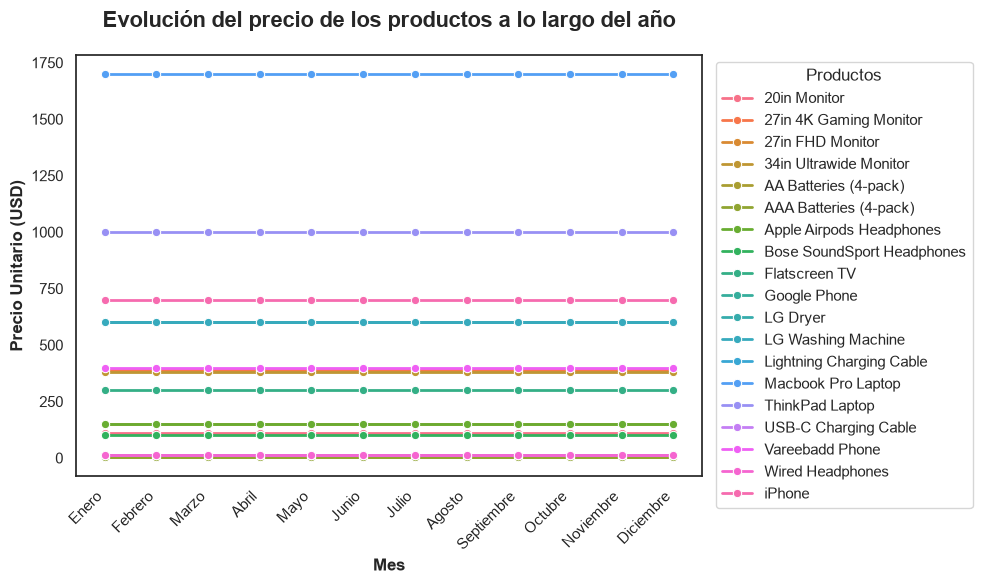

In [72]:
# Agrupación y cálculo del promedio
precio_evolucion = df.groupby(['Mes', 'Producto'])['Precio Unitario'].mean().reset_index()
plt.figure(figsize=(10, 6))
# Creación del gráfico de líneas
sns.lineplot(
    data=precio_evolucion,
    x='Mes',
    y='Precio Unitario',
    hue='Producto',  
    marker='o',      
    linewidth=2
)
plt.title('Evolución del precio de los productos a lo largo del año', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mes', fontsize=12, fontweight='bold')
plt.ylabel('Precio Unitario (USD)', fontsize=12, fontweight='bold')
plt.xticks(ticks=range(1, 13), labels=MESES_NOMBRES, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Productos', facecolor='white')
plt.tight_layout()
plt.show()

Oferta de precios anual: Sin cambios en los precios a lo largo del año. 

## 4.2 Comportamiento de las ventas en los distintos meses:


### 4.2.1 ¿Cómo variaron las ventas a lo largo de los diferentes meses?
Demanda de producto por mes. 
Nota: Se prueban distintas opciones de gráfico

In [73]:
meses_mas_ventas = df.groupby('Mes')['Venta'].sum().sort_values(ascending=False)
print("los meses con mas ventas: ", meses_mas_ventas)

los meses con mas ventas:  Mes
12    4613443.34
10    3736726.88
4     3390670.24
11    3199603.20
5     3152606.75
3     2807100.38
7     2647775.76
6     2577802.26
8     2244467.88
2     2202022.42
9     2097560.13
1     1822256.73
Name: Venta, dtype: float64


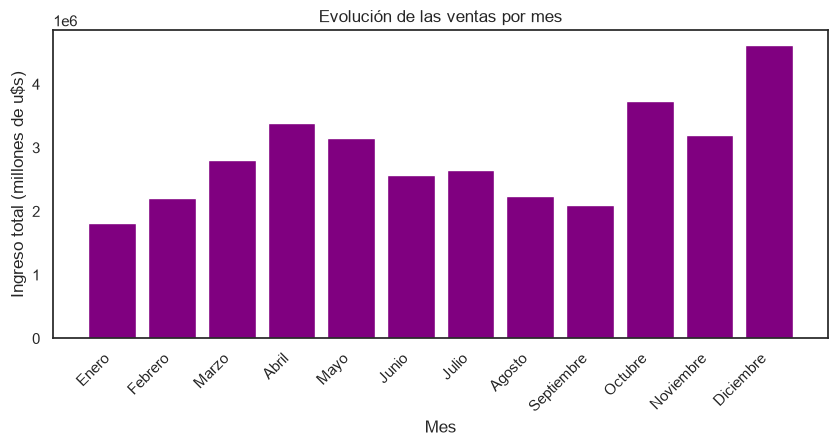

In [74]:
# Gráfico en histograma versión 1 - colores por nombre
plt.figure(figsize=(10,4))
plt.bar(meses_mas_ventas.index, meses_mas_ventas.values, color="purple")
plt.title("Evolución de las ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ingreso total (millones de u$s)")
plt.xticks(ticks=range(1, 13), labels=MESES_NOMBRES, rotation=45, ha='right')
plt.show()

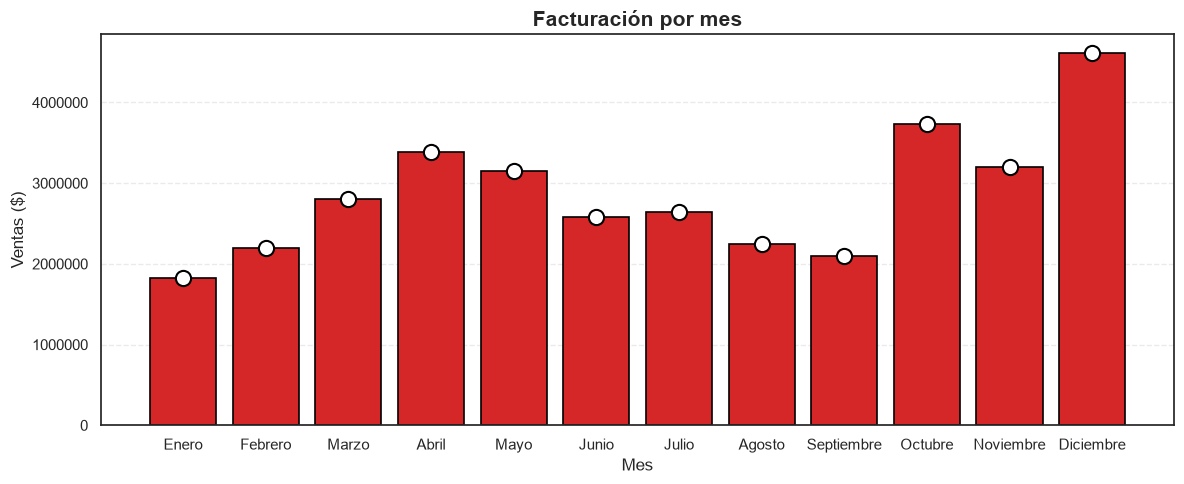

In [75]:
# Gráfico en histograma versión 2 - colores en hexadecimal
ventas_ordenadas = meses_mas_ventas.sort_index()
plt.figure(figsize=(12, 5))
x = ventas_ordenadas.index
y = ventas_ordenadas.values
plt.bar(x, y, color="#d62728", edgecolor="black", linewidth=1.2)
plt.scatter(x, y, color="white", s=120, edgecolor="black", linewidth=1.5, zorder=3)
plt.title("Facturación por mes", fontsize=15, fontweight="bold")
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Ventas ($)", fontsize=12)
plt.xticks(x, MESES_NOMBRES)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

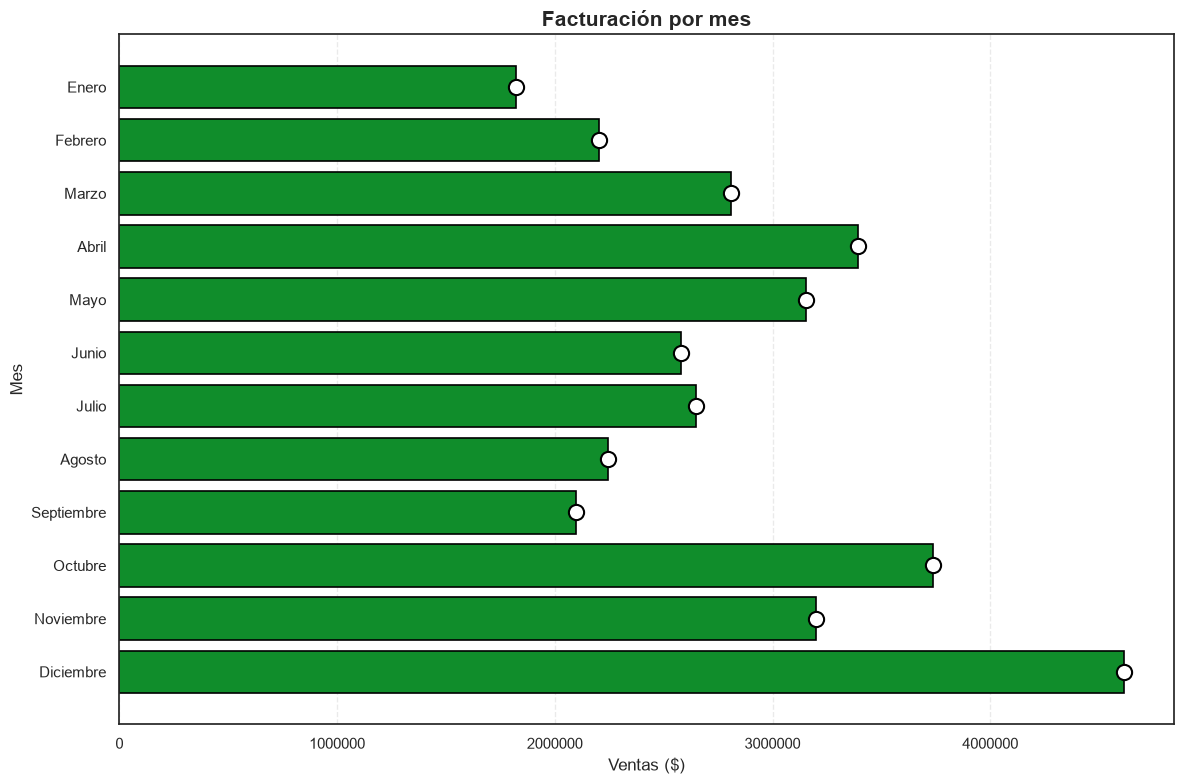

In [76]:
# Gráfico de histograma con barras horizontales

plt.figure(figsize=(12, 8)) 
y = ventas_ordenadas.index
x = ventas_ordenadas.values
plt.barh(y, x, color="#108D2B", edgecolor="black", linewidth=1.2)
plt.scatter(x, y, color="white", s=120, edgecolor="black", linewidth=1.5, zorder=3)
# Invertir eje para que enero quede arriba
plt.gca().invert_yaxis()
plt.title("Facturación por mes", fontsize=15, fontweight="bold")
plt.xlabel("Ventas ($)", fontsize=12)
plt.ylabel("Mes", fontsize=12)
plt.yticks(y, MESES_NOMBRES)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


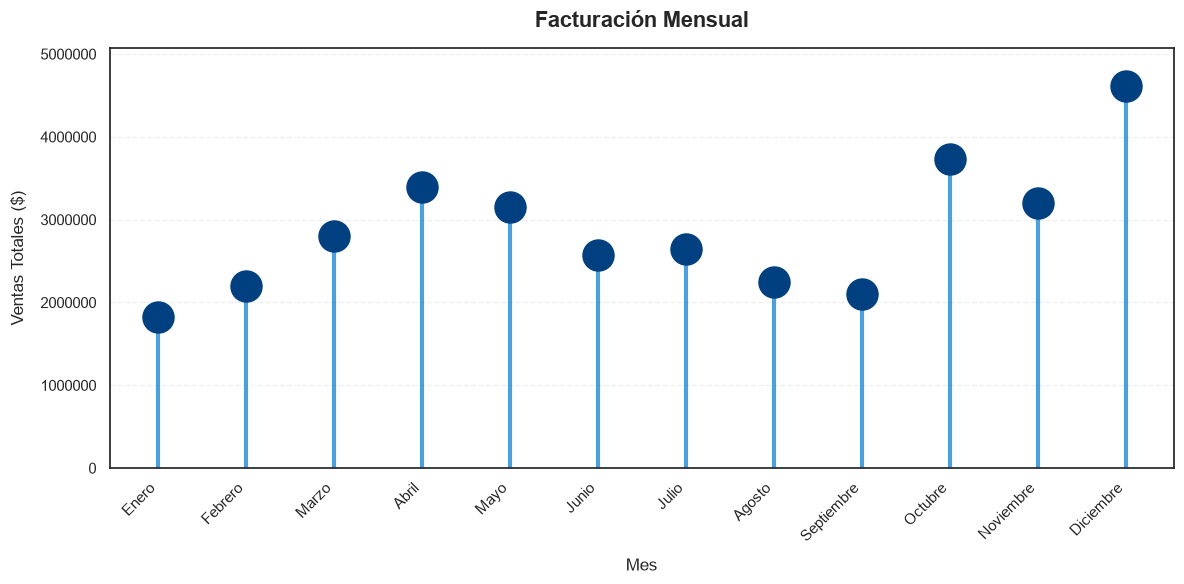

In [77]:
# Gráfico opcion scatter
x = ventas_ordenadas.index
y = ventas_ordenadas.values
plt.figure(figsize=(12, 6))
plt.vlines(x=x, ymin=0, ymax=y, color='#007ACC', alpha=0.7, linewidth=3)
plt.scatter(x, y, s=500, color='#004080', zorder=3)
plt.title("Facturación Mensual", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Mes", fontsize=12, labelpad=10)
plt.ylabel("Ventas Totales ($)", fontsize=12, labelpad=10)
plt.xticks(x, MESES_NOMBRES, rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.ylim(0, max(y) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Tabla de ventas por mes

In [78]:
# Tabla de ventas totales por mes 
tabla_ventas = df.groupby(['Mes', 'Mes_Nombre'])['Venta'].sum().reset_index()
tabla_ventas = tabla_ventas.sort_values('Mes')

tabla_estilizada = tabla_ventas[['Mes_Nombre', 'Venta']].style.format({
    'Venta': '${:,.2f}'  
})\
.hide(axis="index")\
.set_properties(**{'text-align': 'center', 'font-size': '14px'})\
.set_table_styles([
    dict(selector="th", props=[("text-align", "center"), ("background-color", "#333333"), ("color", "white"), ("font-size", "14px")])
])\
.set_caption("Ventas Totales por Mes")

# Mostrar la tabla y exportación de imagen para agregar a informe
display(tabla_estilizada)
dfi.export(tabla_estilizada, 'tabla_ventas.png', table_conversion='matplotlib')

KeyError: 'Mes_Nombre'

### 4.2.2 ¿Hubo algún mes que se destacó en términos de ventas?

Mes con mayor ingreso: Diciembre
Ingreso total: $4,613,443.34


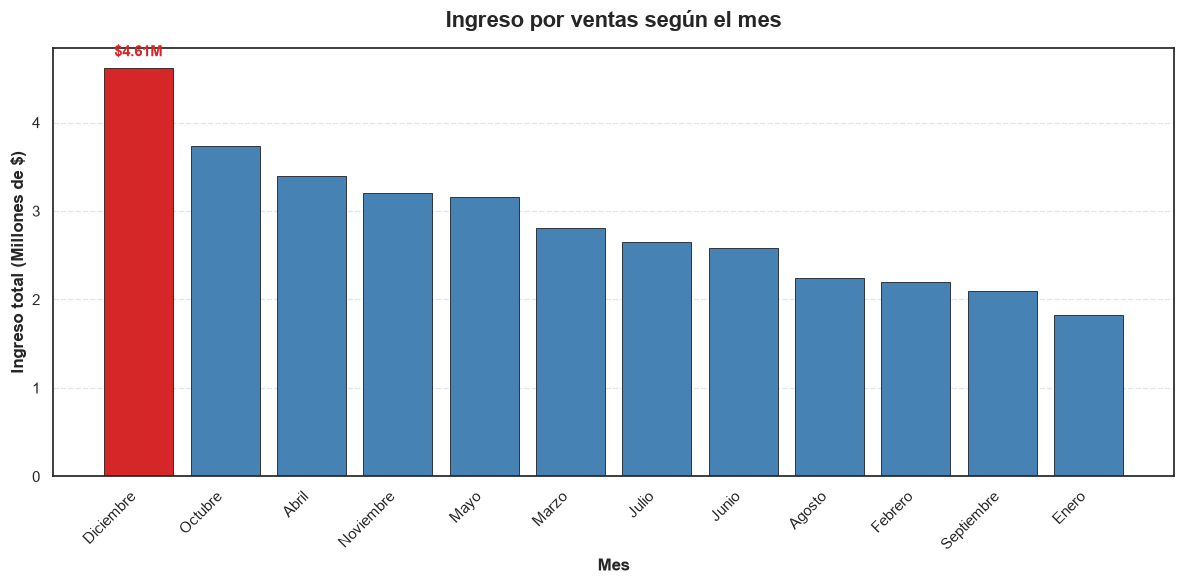

In [ ]:
# usando 'meses_mas_ventas' obtenemos el índice para numero de mes
numero_mes_top = meses_mas_ventas.index[0] 
ingreso_top = meses_mas_ventas.values[0]

# Mapeamos el número del mes usando lista MESES_NOMBRES
nombre_mes_top = MESES_NOMBRES[numero_mes_top - 1] 
print(f"Mes con mayor ingreso: {nombre_mes_top}")
print(f"Ingreso total: ${ingreso_top:,.2f}")

# reordenamos el indice
ingresos_ordenados = meses_mas_ventas.reset_index()
ingresos_ordenados['Nombre Mes'] = ingresos_ordenados['Mes'].apply(lambda x: MESES_NOMBRES[x - 1])
valores_millones = ingresos_ordenados["Venta"] / 1_000_000
meses = ingresos_ordenados["Nombre Mes"]

# Destacamos el mes con más ventas
colores = [
    "#d62728" if mes == nombre_mes_top else "steelblue" 
    for mes in meses
]
fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(
    meses, 
    valores_millones, 
    color=colores,
    edgecolor="black",
    linewidth=0.5
)
ax.text(
    x=0, 
    y=valores_millones.iloc[0] + 0.1, 
    s=f"${valores_millones.iloc[0]:.2f}M", 
    ha="center", 
    va="bottom",
    fontsize=11,
    fontweight="bold",
    color="#d62728"
)

#  Títulos y estilo general
ax.set_title("Ingreso por ventas según el mes", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Mes", fontsize=12, fontweight="bold")
ax.set_ylabel("Ingreso total (Millones de $)", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 4.2.3 ¿Cuál es el ingreso total generado por mes?

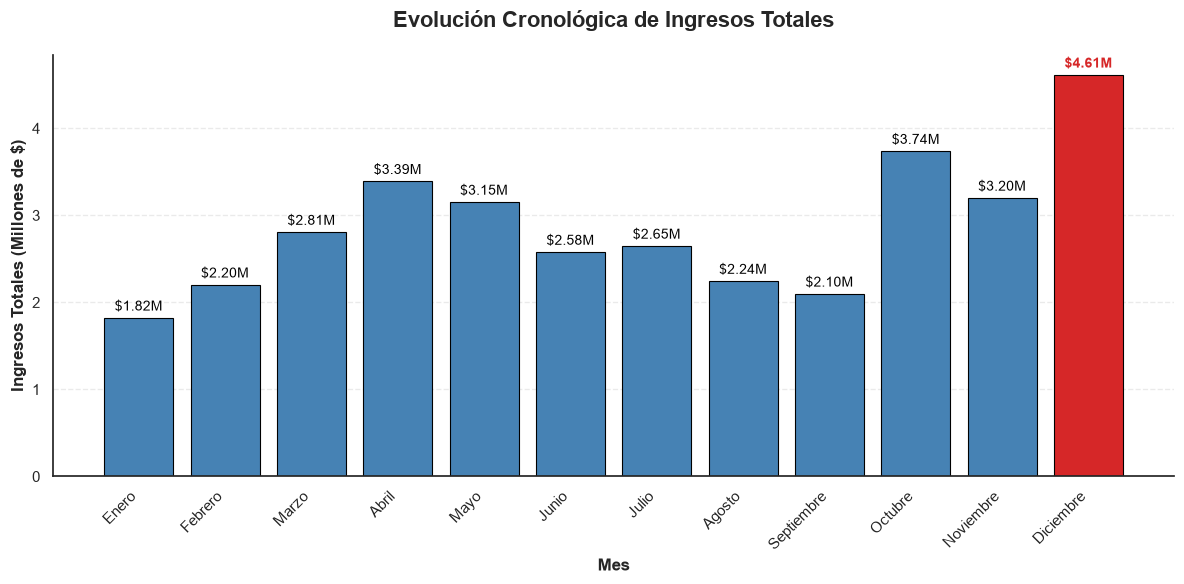

In [ ]:
df_mes = df.groupby('Mes').agg(
    unidades_vendidas=('Cantidad Pedida', 'sum'),
    ingresos_totales=('Venta', 'sum'),
    precio_promedio=('Precio Unitario', 'mean')
).reset_index()
#  Transformamos los ingresos a millones para simplificar la lectura
df_mes['ingresos_millones'] = df_mes['ingresos_totales'] / 1_000_000

# Identificamos el índice del mes con mayores ingresos para destacarlo visualmente
idx_max = df_mes['ingresos_totales'].idxmax()
colores = ['#d62728' if i == idx_max else 'steelblue' for i in range(len(df_mes))]

# Configuración del gráfico 
fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(
    MESES_NOMBRES, 
    df_mes['ingresos_millones'], 
    color=colores, 
    edgecolor='black', 
    linewidth=0.8
)
for i, barra in enumerate(barras):
    altura = barra.get_height()
    peso = "bold" if i == idx_max else "normal"
    color_texto = "#d62728" if i == idx_max else "black"
    ax.text(
        x=barra.get_x() + barra.get_width() / 2, 
        y=altura + 0.05,                        
        s=f"${altura:.2f}M",                    
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight=peso,
        color=color_texto
    )

ax.set_title("Evolución Cronológica de Ingresos Totales", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Mes", fontsize=12, fontweight='bold')
ax.set_ylabel("Ingresos Totales (Millones de $)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax.spines['top'].set_visible(False)  
ax.spines['right'].set_visible(False) 
ax.grid(axis='y', linestyle='--', alpha=0.4) 
ax.set_axisbelow(True) 
plt.tight_layout()
plt.show()

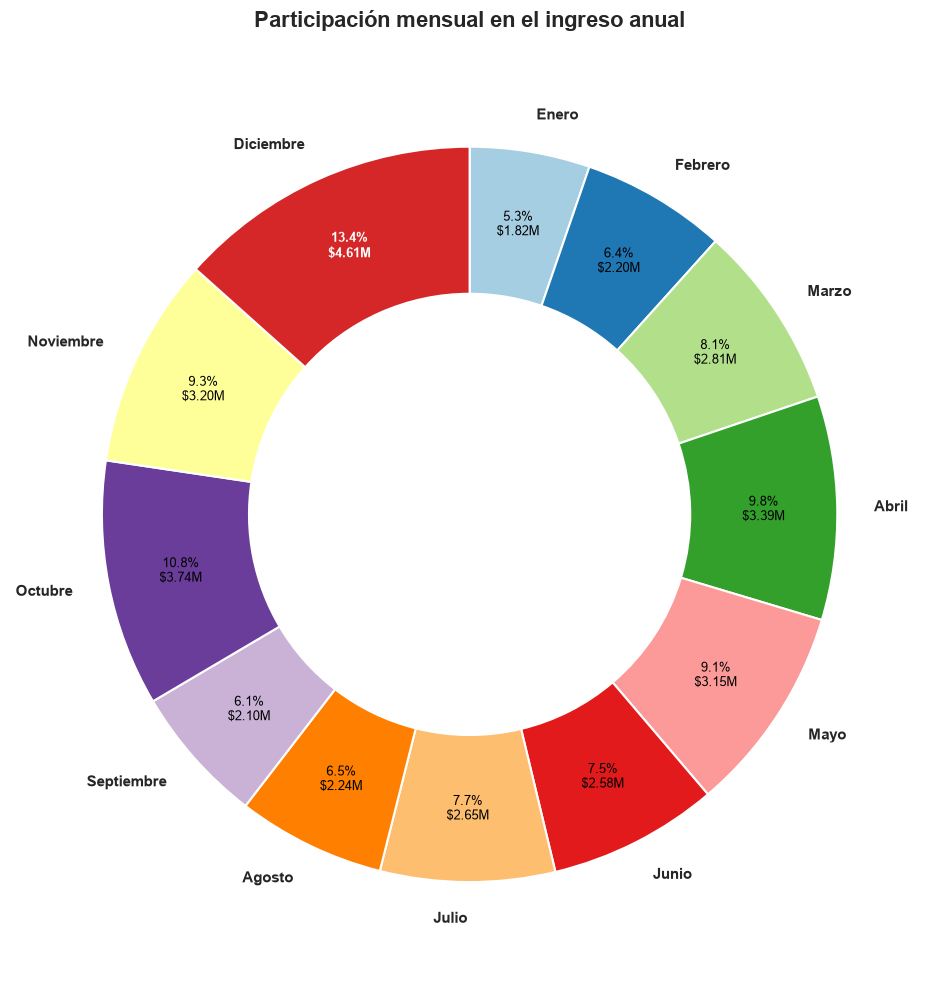

In [ ]:
# Gráfico de Torta con porcentajes
fig, ax = plt.subplots(figsize=(10, 10))
def mostrar_porcentaje_y_ventas(porcentaje):
    ingreso = (porcentaje / 100) * df_mes["ingresos_totales"].sum()
    ingreso_millones = ingreso / 1_000_000
    return f"{porcentaje:.1f}%\n${ingreso_millones:.2f}M"

# Mes récord
idx_max = df_mes["ingresos_totales"].idxmax()

# Colores:  rojo fuerte para el máximo
colores = list(sns.color_palette("Paired", 12))
# Prueba de colores con set: Set1, Set2, Set3, Dark2, Paired, Accent
colores[idx_max] = '#d62728' 

# Creamos el gráfico
wedges, texts, autotexts = ax.pie(
    df_mes["ingresos_totales"],
    labels=MESES_NOMBRES,
    colors=colores,
    autopct=mostrar_porcentaje_y_ventas,
    startangle=90,
    counterclock=False,
    pctdistance=0.8,
    wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 1.5}
)
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
for i, autotext in enumerate(autotexts):
    autotext.set_fontsize(9)
    # Contraste de texto: blanco para el rojo intenso, negro para los tonos suaves
    if i == idx_max:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    else:
        autotext.set_color('black')
ax.set_title("Participación mensual en el ingreso anual", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 4.3 Optimización de la publicidad y patrón de ventas por hora.

### 4.3.1 ¿Cuál es el momento ideal del día para presentar la publicidad y aumentar la probabilidad de compra?

In [ ]:
# Ingresos por Hora
pedidos_por_hora = df.groupby('Hora')['ID de Pedido'].count()
print(pedidos_por_hora)

# Ingresos Totales por Hora
ingresos_por_hora = df.groupby('Hora')['Venta'].sum()
print(ingresos_por_hora)

# Productos por hora
productos_por_hora = df.groupby('Hora')['Cantidad Pedida'].sum()
print(productos_por_hora)

Hora
0      3910
1      2350
2      1243
3       831
4       854
5      1321
6      2482
7      4011
8      6256
9      8748
10    10944
11    12411
12    12587
13    12129
14    10984
15    10175
16    10384
17    10899
18    12280
19    12905
20    12228
21    10921
22     8822
23     6275
Name: ID de Pedido, dtype: int64
Hora
0      713721.27
1      460866.88
2      234851.44
3      145757.89
4      162661.01
5      230679.82
6      448113.00
7      744854.12
8     1192348.97
9     1639030.58
10    1944286.77
11    2300610.24
12    2316821.34
13    2155389.80
14    2083672.73
15    1941549.60
16    1904601.31
17    2129361.61
18    2219348.30
19    2412938.54
20    2281716.24
21    2042000.86
22    1607549.21
23    1179304.44
Name: Venta, dtype: float64
Hora
0      4428
1      2619
2      1398
3       928
4       937
5      1493
6      2810
7      4556
8      7002
9      9816
10    12308
11    14005
12    14202
13    13685
14    12362
15    11391
16    11662
17    12229
18    13802


TEST DE NORMALIDAD: HORA DE COMPRA
Muestra analizada: 185,950 registros
Media: 14.41
Mediana: 15.00
Desviación estándar: 5.42
Asimetría (skewness): -0.530
Curtosis: -0.129



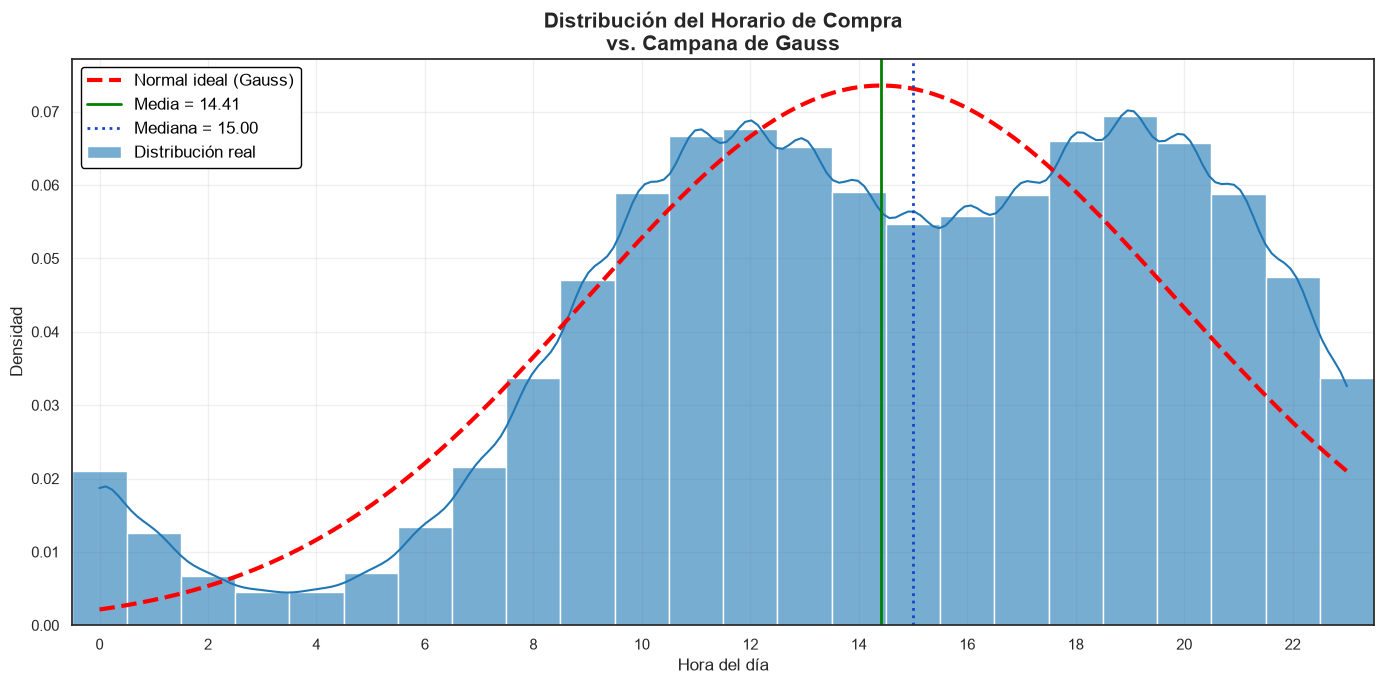

In [ ]:
# Comparación de horas de compras con campana de Gauss para ver normalidad de patrón
hora = pd.to_numeric(df['Hora'], errors='coerce').dropna().astype(float)
print("=" * 60)
print("TEST DE NORMALIDAD: HORA DE COMPRA")
print("=" * 60)

print(f"Muestra analizada: {len(hora):,} registros")
print(f"Media: {hora.mean():.2f}")
print(f"Mediana: {hora.median():.2f}")
print(f"Desviación estándar: {hora.std():.2f}")
print(f"Asimetría (skewness): {hora.skew():.3f}")
print(f"Curtosis: {hora.kurtosis():.3f}")
print()

# GRÁFICO: DISTRIBUCIÓN REAL VS CAMPANA DE GAUSS
fig, ax = plt.subplots(figsize=(14, 7))
sns.histplot(
    hora,
    bins=np.arange(-0.5, 24.5, 1),
    kde=True,
    stat='density',
    alpha=0.60,
    ax=ax,
    label='Distribución real',
    color='#1f77b4'
)

# CAMPANA NORMAL TEÓRICA
media = hora.mean()
desvio = hora.std()
x = np.linspace(
    0,
    23,
    500
)

y = stats.norm.pdf(
    x,
    loc=media,
    scale=desvio
)

ax.plot(
    x,
    y,
    linestyle='--',
    linewidth=3,
    label='Normal ideal (Gauss)',
    color='red'
)

# LÍNEA DE LA MEDIA
ax.axvline(
    media,
    linestyle='-',
    linewidth=2,
    label=f'Media = {media:.2f}',
    color='green'
)

# LÍNEA DE LA MEDIANA
mediana = hora.median()

ax.axvline(
    mediana,
    linestyle=':',
    linewidth=2,
    label=f'Mediana = {mediana:.2f}',
    color='#1645C7'
)
# CONFIGURACIÓN DEL GRÁFICO
ax.set_title(
    'Distribución del Horario de Compra\nvs. Campana de Gauss',
    fontsize=15,
    fontweight='bold'
)
ax.set_xlabel(
    'Hora del día',
    fontsize=12
)
ax.set_ylabel(
    'Densidad',
    fontsize=12
)
ax.set_xlim(
    -0.5,
    23.5
)
ax.set_xticks(
    range(0, 24, 2)
)
ax.grid(
    alpha=0.3
)
ax.legend(
    
    facecolor='white',      
    edgecolor='black',     
    framealpha=1,           
    labelcolor='black',    
    fontsize=12

)

plt.tight_layout()
plt.show()

### 4.3.2 ¿Cómo cambian los patrones de ventas por hora a lo largo del año?

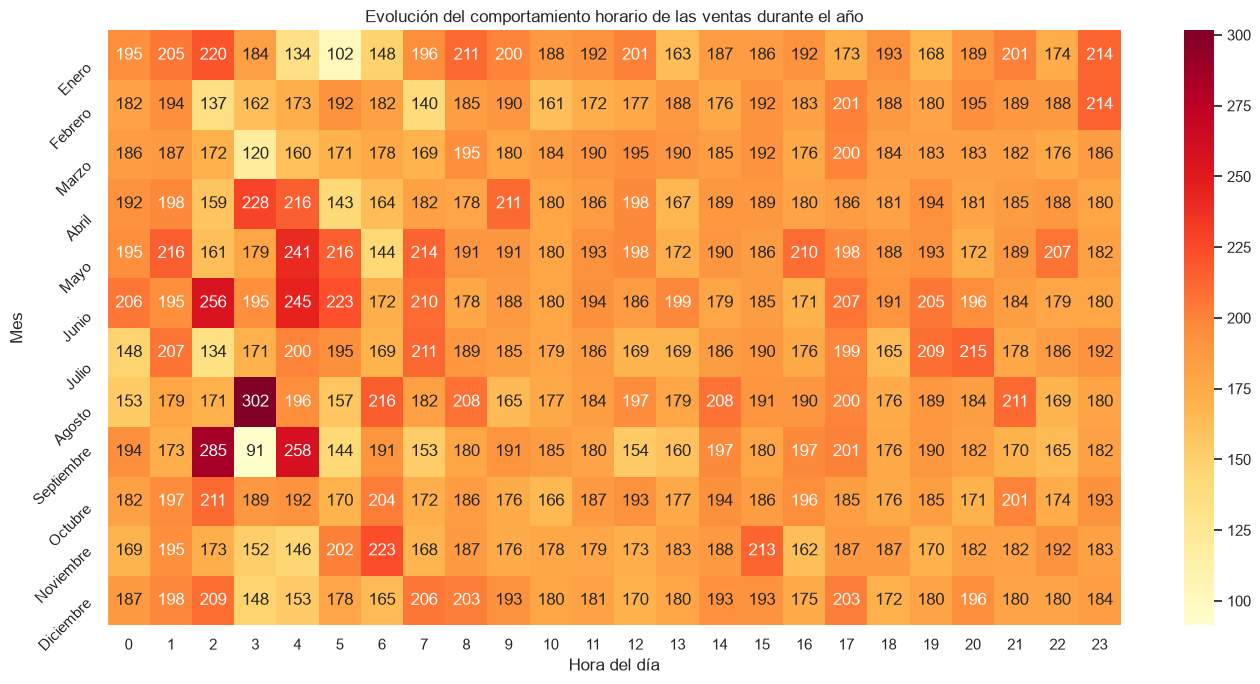

In [ ]:
# Mapa de calor de compras distribuidas por mes y hora
heatmap_data = df.pivot_table(
    index="Mes",
    columns="Hora",
    values="Venta",
    aggfunc="mean"
)
plt.figure(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)
plt.xlabel("Hora del día")
plt.ylabel("Mes")
plt.title("Evolución del comportamiento horario de las ventas durante el año")
plt.yticks(x, MESES_NOMBRES, rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.3.3 ¿Hay modificaciones en los patrones de ventas durante las horas de mayor actividad en los distintos meses?

In [ ]:
df.head(2)

NameError: name 'df' is not defined

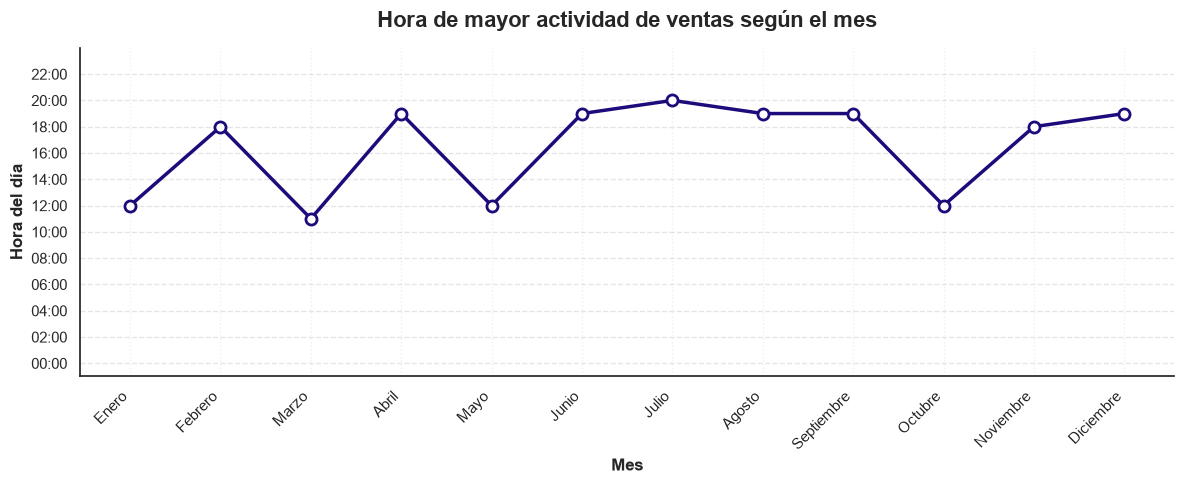

In [ ]:
# Agrupar los datos por Mes y Hora, calculando el total de ventas (por si no la tenías definida en esta celda)
ventas_mes_hora = df.groupby(['Mes', 'Hora'])['Venta'].sum().reset_index()

# Encontrar la hora de mayor actividad
hora_pico_por_mes = ventas_mes_hora.sort_values(by=['Mes', 'Venta'], ascending=[True, False]).groupby('Mes').head(1)
fig, ax = plt.subplots(figsize=(12, 5))
# Gráfico
ax.plot(
    hora_pico_por_mes['Mes'], 
    hora_pico_por_mes['Hora'], 
    marker="o", 
    color="#1c0b7b",      
    linewidth=2.5, 
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2
)

# Formato de textos, títulos y ejes
ax.set_title("Hora de mayor actividad de ventas según el mes", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Mes", fontsize=12, fontweight='bold')
ax.set_ylabel("Hora del día", fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES_NOMBRES, rotation=45, ha="right")
ax.set_yticks(range(0, 24, 2)) 
ax.set_yticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_ylim(-1, 24) 
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.grid(axis="x", linestyle=":", alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Renderizado final
plt.tight_layout()
plt.show()

# 5. Distribución de ventas por ubicación

## 5.1 ¿En qué ciudades se han registrado las mayores ventas? 

In [ ]:

df_ventas_ciudad = ciudades_con_mas_ventas.reset_index()

# Gráfico de barras interactivo para Ventas Totales
fig = px.bar(
    df_ventas_ciudad, 
    x='Ciudad', 
    y='Venta',              
    color='Venta',
    text_auto='.2s',        
    title='Ventas Totales por Ciudad',
    labels={'Venta': 'Ventas Totales ($)'},
    color_continuous_scale='Turbo' 
)

# paletas probadas: Tealgrn (muy claro), Viridis, Plasma, Inferno (Austin queda muy oscuro), Magma,Cividis, Turbo, Electric

# Mejoramos el diseño del texto y el fondo
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.update_layout(
    xaxis_title="Ciudad",
    yaxis_title="Ventas Totales ($)", 
    plot_bgcolor='white',
    hovermode="x"
)

fig.show()

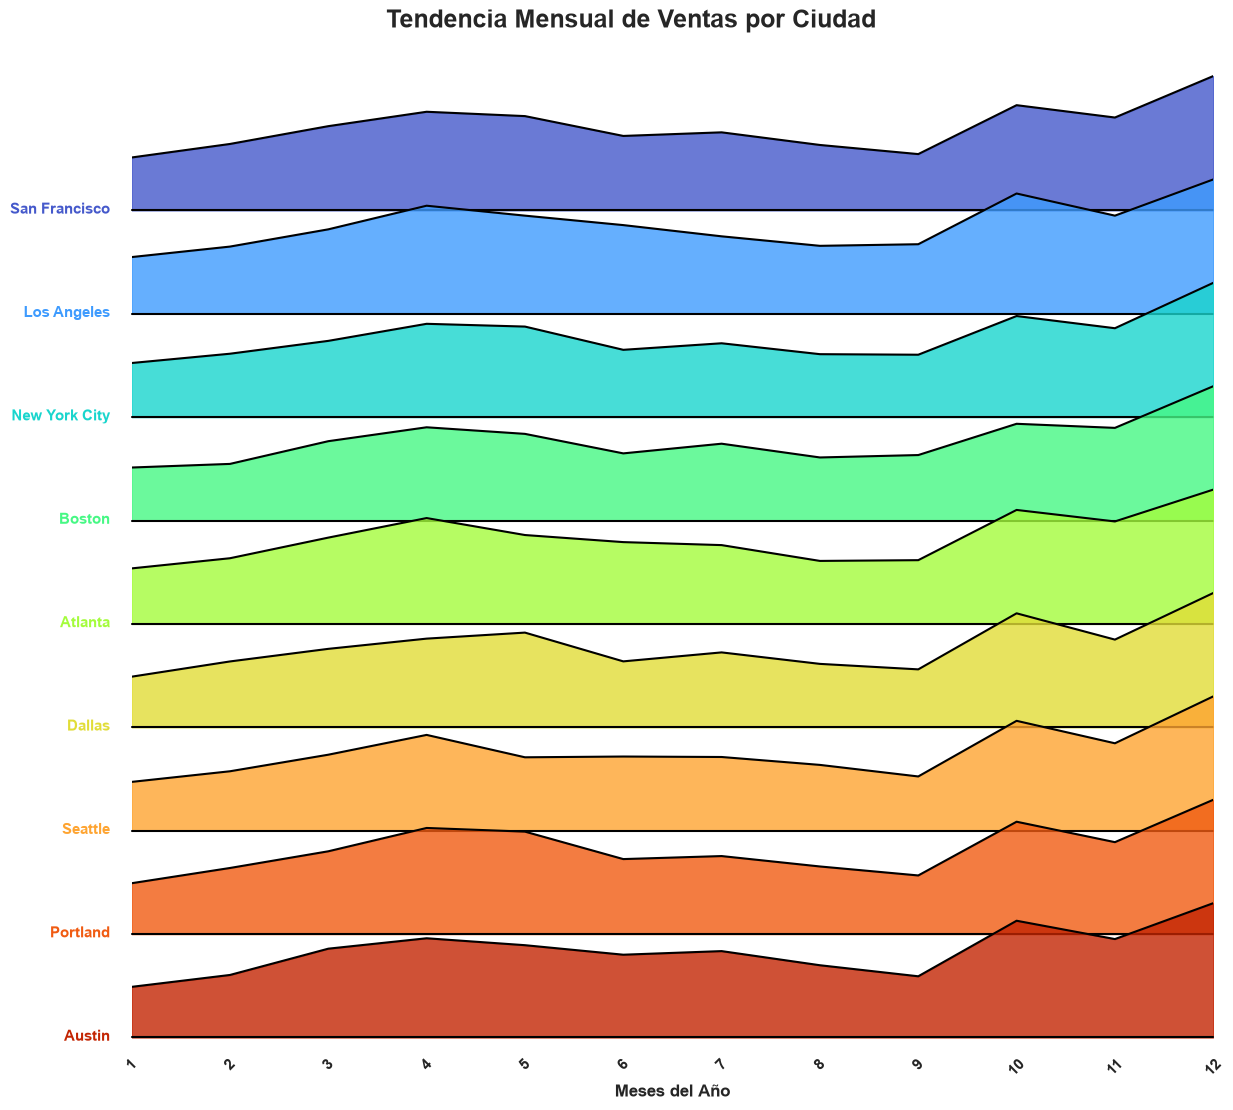

In [ ]:
# Agrupamos las ventas totales por Ciudad y por Mes
df_tendencia = df.groupby(['Ciudad', 'Mes'])['Venta'].sum().reset_index()

# Ordenamos las ciudades por ventas totales 
orden_ciudades = df.groupby('Ciudad')['Venta'].sum().sort_values(ascending=False).index
df_tendencia['Ciudad'] = pd.Categorical(df_tendencia['Ciudad'], categories=orden_ciudades, ordered=True)
df_tendencia = df_tendencia.sort_values(['Ciudad', 'Mes'])

# prueba de paleta de colores
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
paleta = sns.color_palette("turbo", len(orden_ciudades))

# 3. Creamos el FacetGrid separando por 'Ciudad'

g = sns.FacetGrid(df_tendencia, row="Ciudad", hue="Ciudad", aspect=10, height=1.2, palette=paleta, sharey=False)

# funcion para color
def plot_area(x, y, color, **kwargs):
    ax = plt.gca()
    # línea principal
    ax.plot(x, y, color="black", lw=1.5)
    # área bajo la curva
    ax.fill_between(x, y, color=color, alpha=0.8)

# mapa para mes y venta
g.map(plot_area, "Mes", "Venta")
g.map(plt.axhline, y=0, lw=1.5, clip_on=False, color="black")
g.fig.subplots_adjust(hspace=-0.3)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# nombres de ciudades
for i, ax in enumerate(g.axes.flat):
    if i < len(orden_ciudades):
        ax.text(-0.02, 0.05, orden_ciudades[i], fontweight='bold', fontsize=11,
                color=paleta[i], ha="right", va="center", transform=ax.transAxes)


g.figure.suptitle('Tendencia Mensual de Ventas por Ciudad', fontsize=18, fontweight='bold', y=1.02)

plt.xticks(range(1, 13), meses_nombres, rotation=45, fontsize=11, fontweight='bold')
plt.xlabel('Meses del Año', fontsize=12, fontweight='bold')

g.set(xlim=(1, 12)) 

plt.show()

## 5.2 ¿Cómo se comparan las ventas en diferentes estados o regiones?

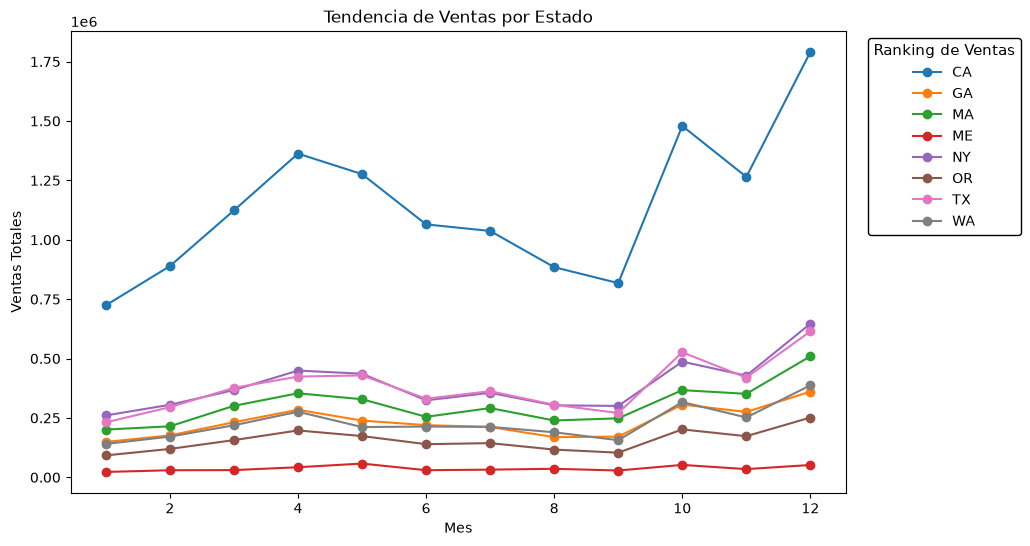

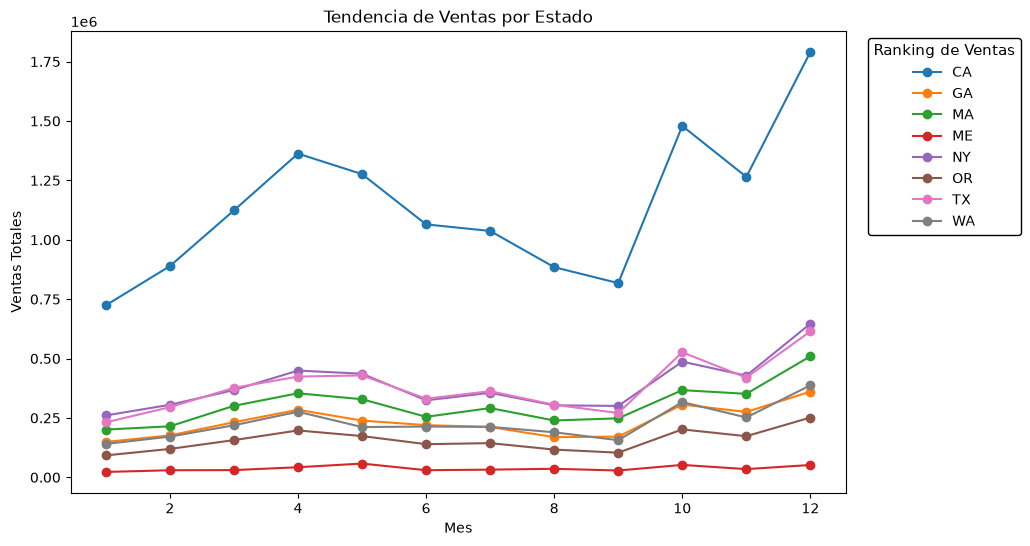

In [ ]:
fig_grafico, ax = plt.subplots(figsize=(10, 6))

# Agrupación
df_tendencia_estado = df.groupby(['Estado', 'Mes'])['Venta'].sum().reset_index()

# Gráfico
for estado in df_tendencia_estado['Estado'].unique():
    datos_estado = df_tendencia_estado[df_tendencia_estado['Estado'] == estado]
    ax.plot(
        datos_estado['Mes'],
        datos_estado['Venta'],
        marker='o',
        label=estado
    )

# Leyenda con fondo blanco
ax.legend(
    title='Ranking de Ventas',
    title_fontsize=11,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    facecolor='white',
    framealpha=1,
    edgecolor='black',
    frameon=True
)

# Títulos
ax.set_title('Tendencia de Ventas por Estado')
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas Totales')

# La variable final contiene TODO el gráfico
fig_grafico


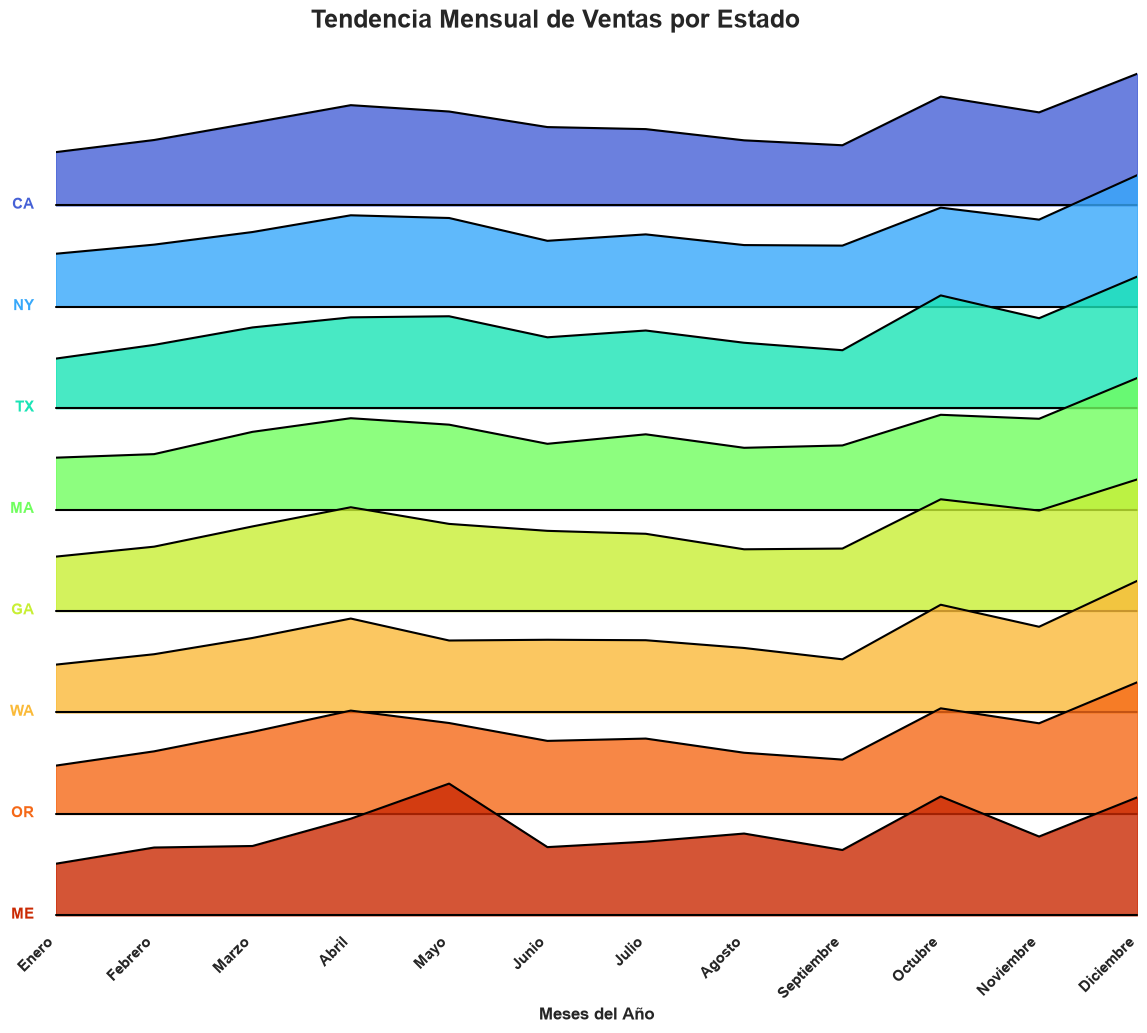

In [ ]:
# Agrupamos las ventas totales por Estado y por Mes
df_tendencia_estado = df.groupby(['Estado', 'Mes'])['Venta'].sum().reset_index()

# Ordenamos los estados por ventas totales (de mayor a menor)
orden_estados = df.groupby('Estado')['Venta'].sum().sort_values(ascending=False).index

# Convertimos la columna 'Estado' a categórica para forzar el orden en el gráfico
df_tendencia_estado['Estado'] = pd.Categorical(df_tendencia_estado['Estado'], categories=orden_estados, ordered=True)
df_tendencia_estado = df_tendencia_estado.sort_values(['Estado', 'Mes'])

# 
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
paleta = sns.color_palette("turbo", len(orden_estados))
g = sns.FacetGrid(df_tendencia_estado, row="Estado", hue="Estado", aspect=10, height=1.2, palette=paleta, sharey=False)
def plot_area(x, y, color, **kwargs):
    ax = plt.gca()
    # línea principal superior
    ax.plot(x, y, color="black", lw=1.5)
    # área sombreada bajo la curva
    ax.fill_between(x, y, color=color, alpha=0.8)
g.map(plot_area, "Mes", "Venta")
g.map(plt.axhline, y=0, lw=1.5, clip_on=False, color="black")

g.fig.subplots_adjust(hspace=-0.3)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# nombres de los estados
for i, ax in enumerate(g.axes.flat):
    if i < len(orden_estados):
        ax.text(-0.02, 0.05, orden_estados[i], fontweight='bold', fontsize=11,
                color=paleta[i], ha="right", va="center", transform=ax.transAxes)

# Título principal de la figura
g.figure.suptitle('Tendencia Mensual de Ventas por Estado', fontsize=18, fontweight='bold', y=1.02)

plt.xticks(range(1, 13), MESES_NOMBRES, rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.xlabel('Meses del Año', fontsize=12, fontweight='bold')
g.set(xlim=(1, 12)) 

plt.show()

# Análisis del producto más vendido

## ¿Cuál es el producto más vendido en general y en cada mes?

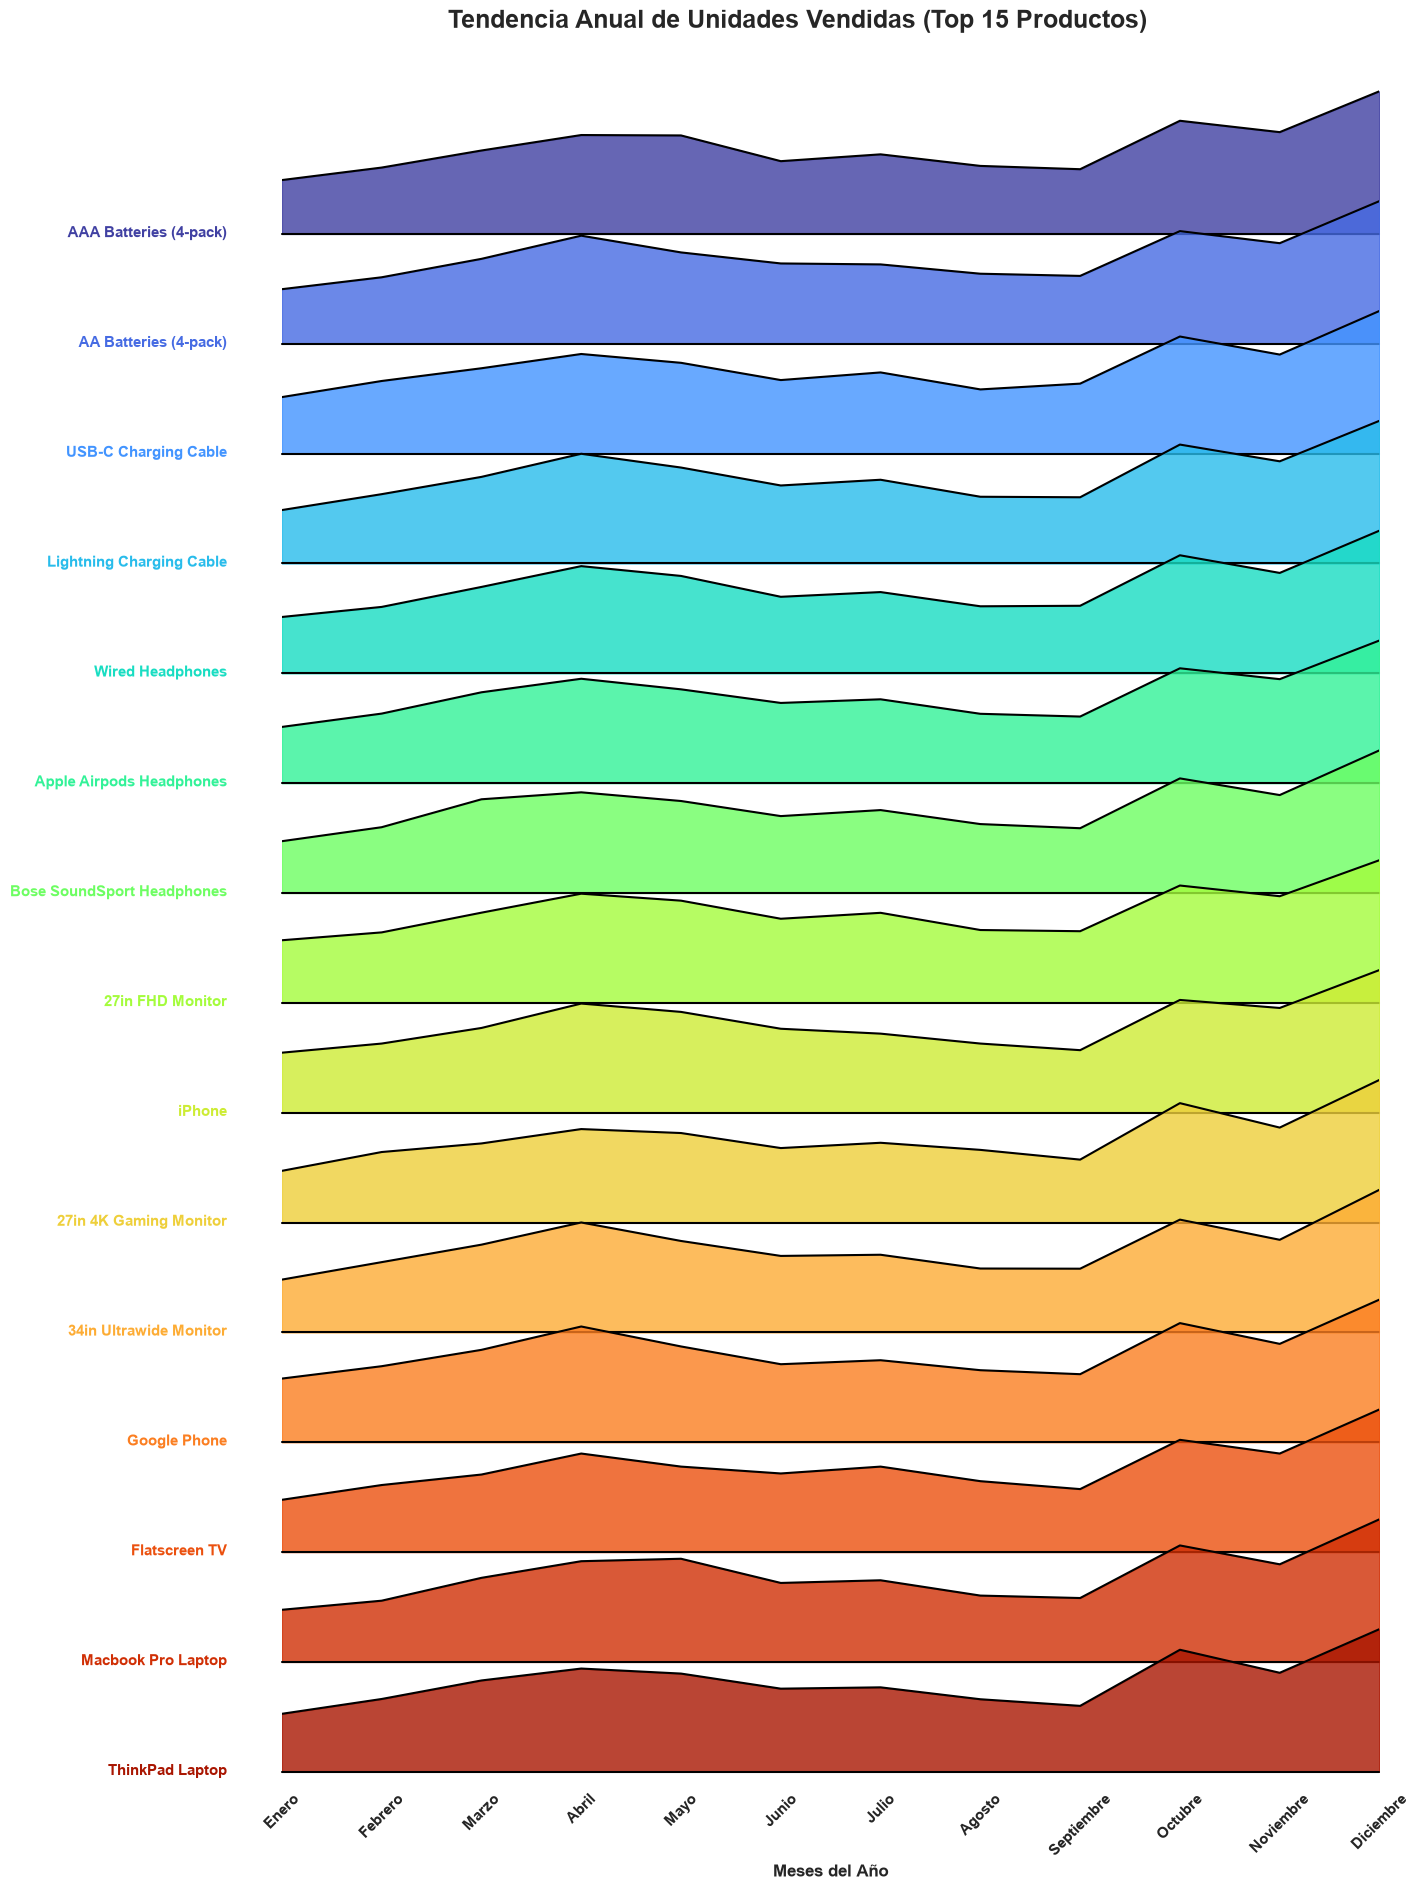

In [ ]:



# Esto evita que el gráfico se vuelva demasiado alto y difícil de leer
top_15_productos = df.groupby('Producto')['Cantidad Pedida'].sum().nlargest(15).index
df_top = df[df['Producto'].isin(top_15_productos)]


df_tendencia_prod = df_top.groupby(['Producto', 'Mes'])['Cantidad Pedida'].sum().reset_index()

df_tendencia_prod['Producto'] = pd.Categorical(df_tendencia_prod['Producto'], categories=top_15_productos, ordered=True)
df_tendencia_prod = df_tendencia_prod.sort_values(['Producto', 'Mes'])


sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
paleta = sns.color_palette("turbo", len(top_15_productos))


g = sns.FacetGrid(df_tendencia_prod, row="Producto", hue="Producto", aspect=10, height=1.2, palette=paleta, sharey=False)

# efecto de cresta (línea + relleno)
def plot_area(x, y, color, **kwargs):
    ax = plt.gca()
    ax.plot(x, y, color="black", lw=1.5)
    ax.fill_between(x, y, color=color, alpha=0.8)

#  datos de Mes y Cantidad Pedida
g.map(plot_area, "Mes", "Cantidad Pedida")
g.map(plt.axhline, y=0, lw=1.5, clip_on=False, color="black")
g.figure.subplots_adjust(hspace=-0.3)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# nombre de cada producto 
for i, ax in enumerate(g.axes.flat):
    if i < len(top_15_productos):
        # Desplazamos un poco más a la izquierda (-0.05) porque los nombres de productos son largos
        ax.text(-0.05, 0.05, top_15_productos[i], fontweight='bold', fontsize=11,
                color=paleta[i], ha="right", va="center", transform=ax.transAxes)

# Título principal y configuración del eje X
g.figure.suptitle('Tendencia Anual de Unidades Vendidas (Top 15 Productos)', fontsize=18, fontweight='bold', y=1.02)

meses_nombres = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", 
                 "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
plt.xticks(range(1, 13), meses_nombres, rotation=45, fontsize=11, fontweight='bold')
plt.xlabel('Meses del Año', fontsize=12, fontweight='bold')

g.set(xlim=(1, 12))

plt.show()

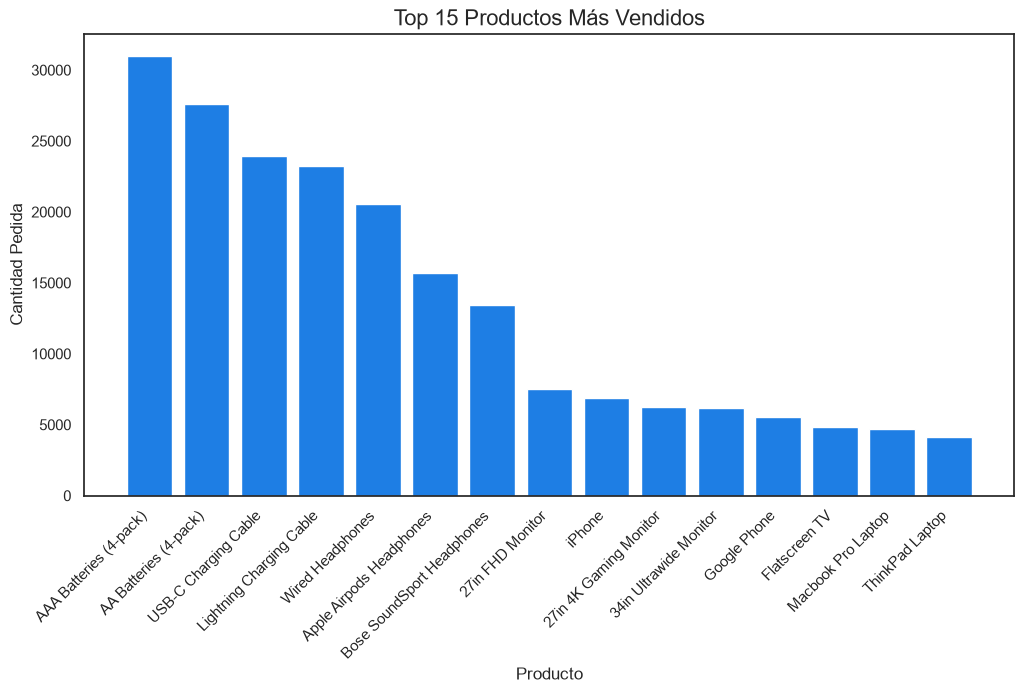

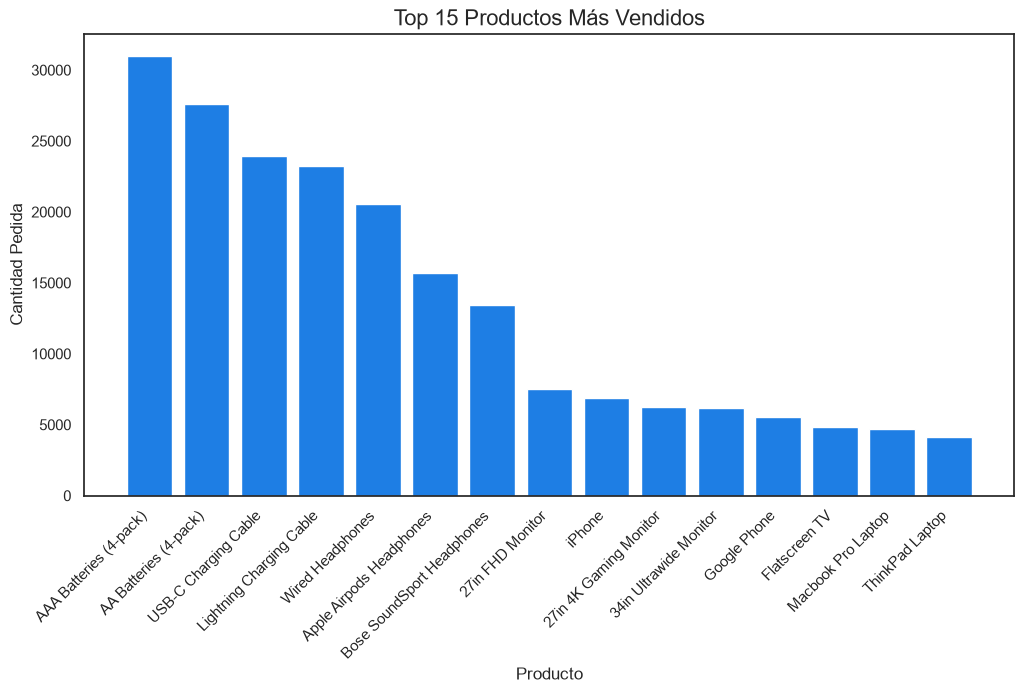

In [ ]:
# Top 15 productos por cantidad pedida
top_15_productos = df.groupby('Producto')['Cantidad Pedida'].sum().nlargest(15)

# Crear figura y eje
fig_top_productos, ax = plt.subplots(figsize=(12, 6))

# Gráfico de barras
ax.bar(top_15_productos.index, top_15_productos.values, color="#1E7EE4")

# Títulos y etiquetas
ax.set_title("Top 15 Productos Más Vendidos", fontsize=16)
ax.set_xlabel("Producto", fontsize=12)
ax.set_ylabel("Cantidad Pedida", fontsize=12)

# Rotar etiquetas para legibilidad
plt.xticks(rotation=45, ha='right')

# Fondo blanco en la leyenda (si la agregás)
# ax.legend(facecolor='white', framealpha=1, edgecolor='black')

# Mostrar figura
fig_top_productos


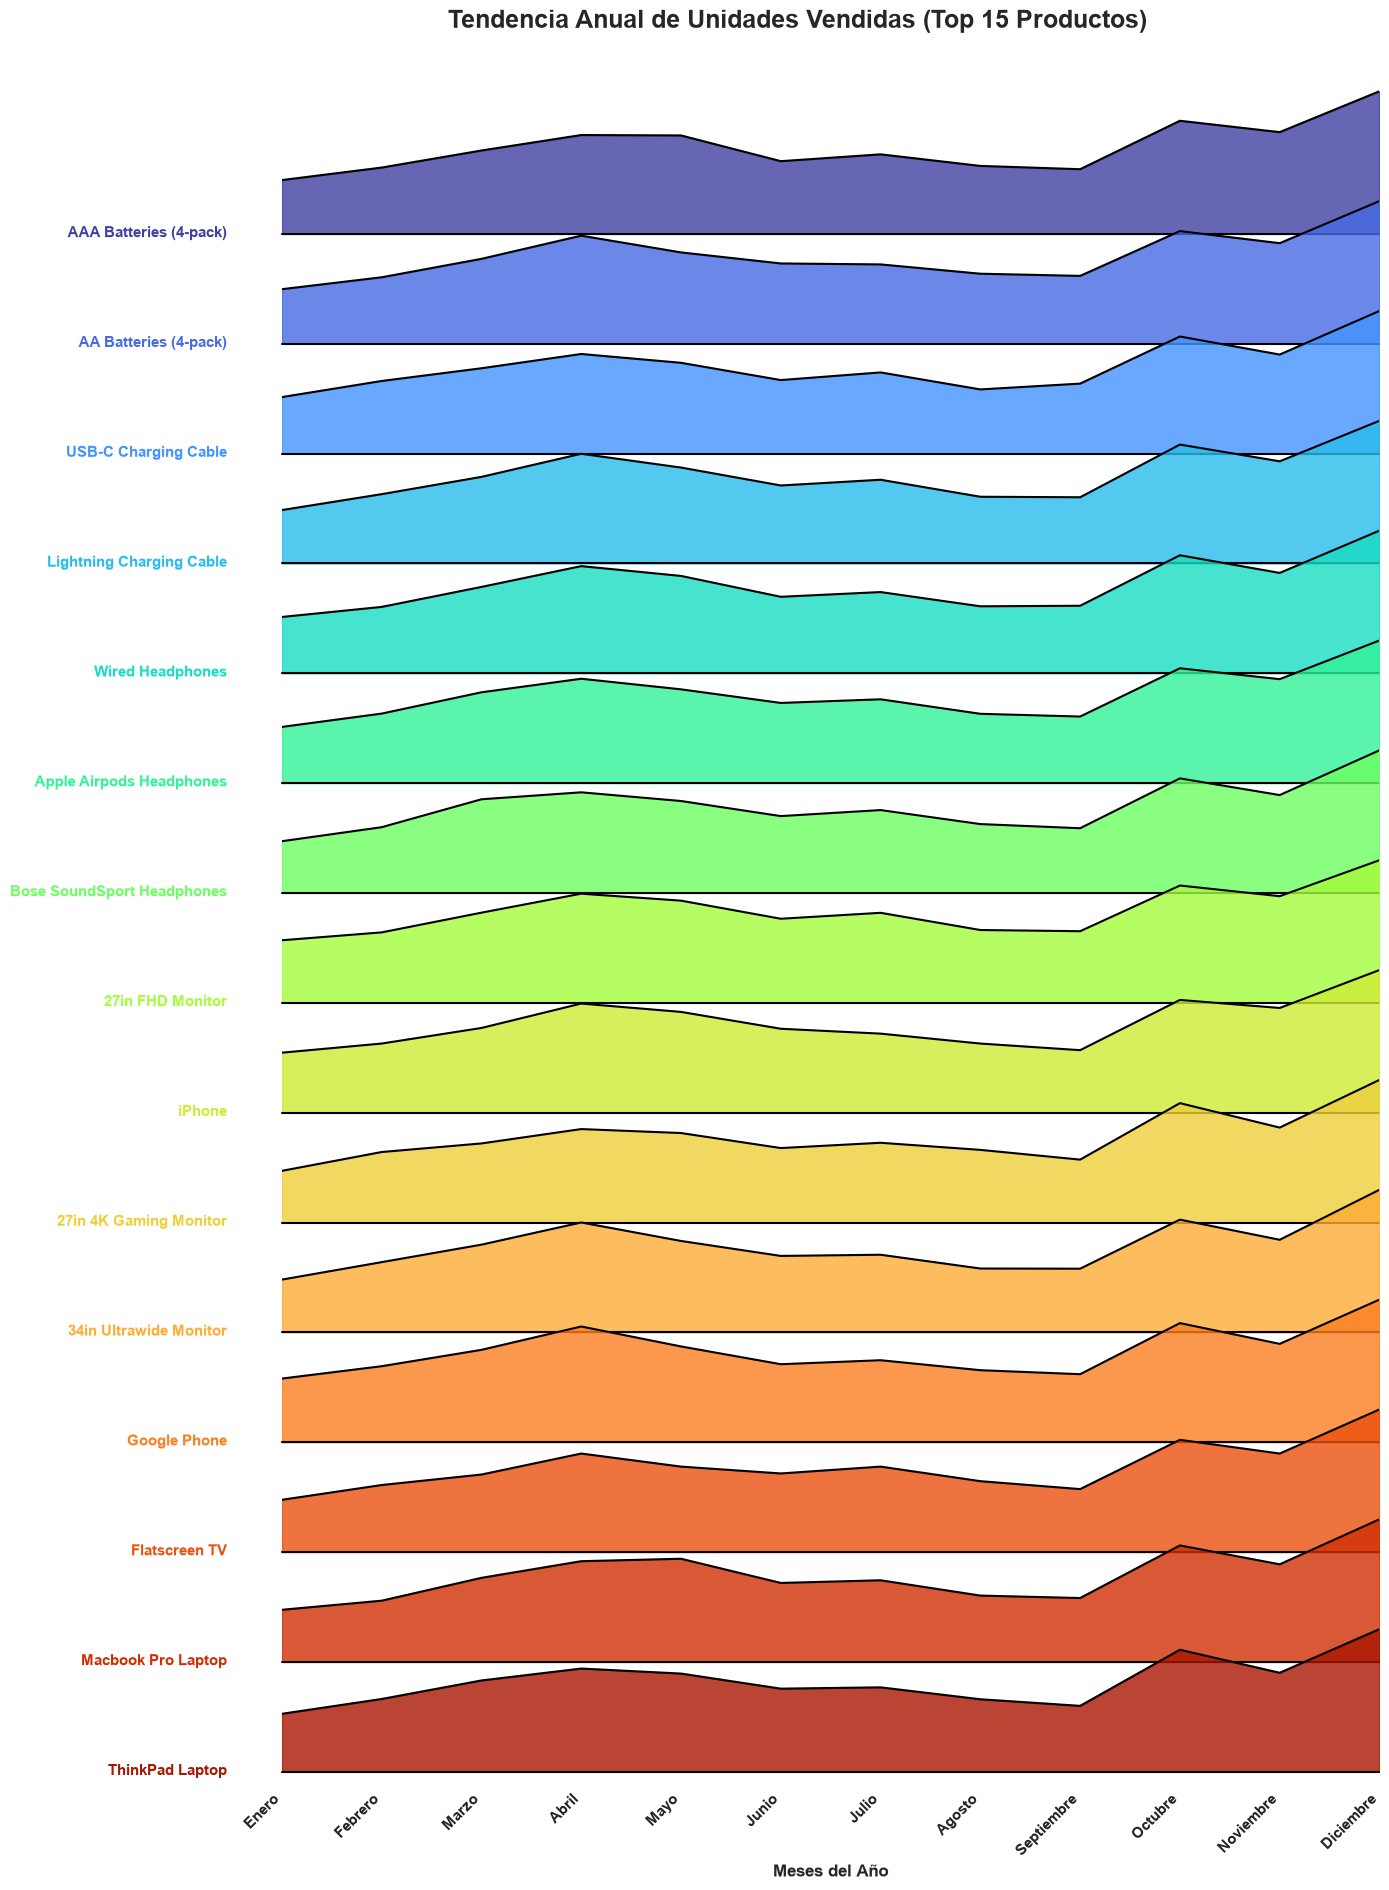

In [ ]:
# 1. Extraemos SOLO los nombres de los 15 productos más vendidos (Esto es un Index, no un DataFrame)
top_15_productos = df.groupby('Producto')['Cantidad Pedida'].sum().nlargest(15).index

# 2. OPTIMIZACIÓN: Filtramos y agrupamos EN UN SOLO PASO (Evitando crear 'df_top')
df_tendencia_prod = (
    df[df['Producto'].isin(top_15_productos)]
    .groupby(['Producto', 'Mes'])['Cantidad Pedida']
    .sum()
    .reset_index()
)

# 3. Forzamos el orden categórico para que el Producto #1 quede arriba en el gráfico
df_tendencia_prod['Producto'] = pd.Categorical(df_tendencia_prod['Producto'], categories=top_15_productos, ordered=True)
df_tendencia_prod = df_tendencia_prod.sort_values(['Producto', 'Mes'])

# 4. Configuración del tema y colores (Ridge Plot)
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
paleta = sns.color_palette("turbo", len(top_15_productos))

g = sns.FacetGrid(df_tendencia_prod, row="Producto", hue="Producto", aspect=10, height=1.2, palette=paleta, sharey=False)

# Función para el efecto de cresta (línea + relleno)
def plot_area(x, y, color, **kwargs):
    ax = plt.gca()
    ax.plot(x, y, color="black", lw=1.5)
    ax.fill_between(x, y, color=color, alpha=0.8)

# Mapeo de datos
g.map(plot_area, "Mes", "Cantidad Pedida")
g.map(plt.axhline, y=0, lw=1.5, clip_on=False, color="black")
g.figure.subplots_adjust(hspace=-0.3)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# 5. Nombre de cada producto (Desplazado a la izquierda por longitud)
for i, ax in enumerate(g.axes.flat):
    if i < len(top_15_productos):
        ax.text(-0.05, 0.05, top_15_productos[i], fontweight='bold', fontsize=11,
                color=paleta[i], ha="right", va="center", transform=ax.transAxes)

# 6. Título y configuración final usando la constante MESES_NOMBRES
g.figure.suptitle('Tendencia Anual de Unidades Vendidas (Top 15 Productos)', fontsize=18, fontweight='bold', y=1.02)

# Usamos ha='right' para alinear correctamente los textos rotados
plt.xticks(range(1, 13), MESES_NOMBRES, rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.xlabel('Meses del Año', fontsize=12, fontweight='bold')

g.set(xlim=(1, 12))
plt.show()

## ¿Qué factores crees que han contribuido al éxito de ese producto en particular?

Los productos más vendidos son las baterias. El precio de las mismas, y tal vez el aumento de requerimiento de energía con momentos festivos e invernales puede influir.

In [ ]:
df.head(2)

,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio,Mes,Dia,dia_semana,mes_nombre,Hora,Ciudad,Estado,Venta
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,19,Viernes,Abril,8,Dallas,TX,23.90
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,7,Domingo,Abril,22,Boston,MA,99.99


In [ ]:

# Agrupamos por producto, obtenemos su precio y sumamos la 'Venta' 
df_ingresos = df.groupby('Producto').agg({
    'Precio Unitario': 'mean',
    'Venta': 'sum'
}).reset_index()

# Ordenar del producto más caro al más barato
df_ingresos = df_ingresos.sort_values(by='Precio Unitario', ascending=False)

# Gráfico
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_ingresos['Producto'],
        y=df_ingresos['Venta'],
        name="Ingreso Total Generado (USD)",
        marker_color='#108D2B', 
        opacity=0.85
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_ingresos['Producto'],
        y=df_ingresos['Precio Unitario'],
        name="Precio Unitario ($)",
        mode='lines+markers',
        marker=dict(color='#E7100D', size=10), # Rojo vibrante
        line=dict(width=3, shape='spline')
    ),
    secondary_y=True,
)

fig.update_layout(
    title_text="Precio del Producto vs. Ingresos Totales Generados",
    title_font=dict(size=22, color='#333333', family="Arial"),
    plot_bgcolor='rgba(245, 245, 245, 0.9)',
    paper_bgcolor='white',
    hovermode="x unified", 
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1
    ),
    margin=dict(t=100, b=120)
)


fig.update_xaxes(title_text="<b>Productos</b> (Ordenados por Precio Descendente)", tickangle=45)

fig.update_yaxes(title_text="<b>Ingreso Total (USD)</b>", secondary_y=False, color='#108D2B', tickprefix="$")
fig.update_yaxes(title_text="<b>Precio Unitario (USD)</b>", secondary_y=True, color='#E7100D', tickprefix="$")

fig.show()

In [ ]:


#  Agrupar, agregar y ordenar en un solo paso (Method Chaining)
df_ingresos = (
    df.groupby('Producto', as_index=False)
    .agg({'Precio Unitario': 'mean', 'Venta': 'sum'})
    .sort_values(by='Precio Unitario', ascending=False)
)

#  Creación del Gráfico
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_ingresos['Producto'],
        y=df_ingresos['Venta'],
        name="Ingreso Total Generado (USD)",
        marker_color='#108D2B', 
        opacity=0.85
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_ingresos['Producto'],
        y=df_ingresos['Precio Unitario'],
        name="Precio Unitario ($)",
        mode='lines+markers',
        marker=dict(color='#E7100D', size=10), # Rojo vibrante
        line=dict(width=3, shape='spline')
    ),
    secondary_y=True,
)

fig.update_layout(
    title_text="Precio del Producto vs. Ingresos Totales Generados",
    title_font=dict(size=22, color='#333333', family="Arial"),
    plot_bgcolor='rgba(245, 245, 245, 0.9)',
    paper_bgcolor='white',
    hovermode="x unified", 
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1
    ),
    margin=dict(t=100, b=120)
)

fig.update_xaxes(title_text="<b>Productos</b> (Ordenados por Precio Descendente)", tickangle=45)

fig.update_yaxes(title_text="<b>Ingreso Total (USD)</b>", secondary_y=False, color='#108D2B', tickprefix="$")
fig.update_yaxes(title_text="<b>Precio Unitario (USD)</b>", secondary_y=True, color='#E7100D', tickprefix="$")

fig.show()

In [ ]:
df.head(1)

,ID de Pedido,Producto,Cantidad Pedida,Precio Unitario,Fecha de Pedido,Dirección de Envio,Mes,Dia,dia_semana,mes_nombre,Hora,Ciudad,Estado,Venta
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,19,Viernes,Abril,8,Dallas,TX,23.9


# Tendencia ventas

## ¿Existe alguna tendencia o patrón en las ventas que se repita a lo largo de los días en los diferentes meses?

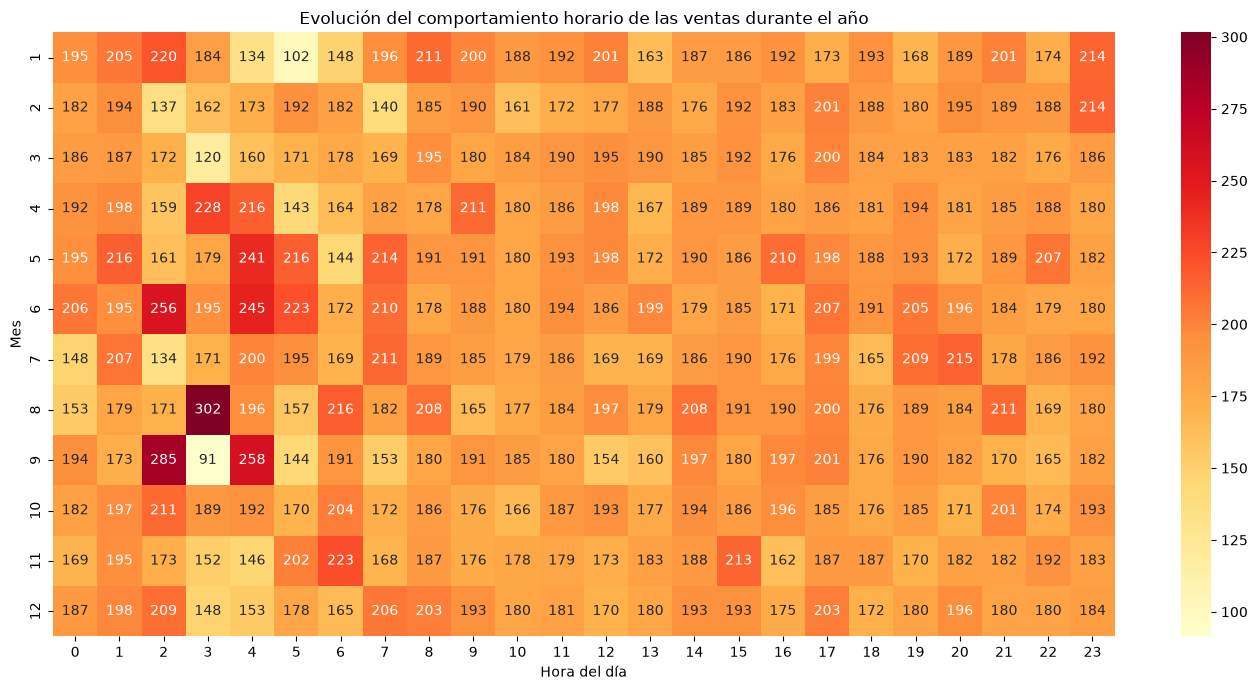

In [ ]:


heatmap_data = df.pivot_table(
    index="Mes",
    columns="Hora",
    values="Venta",
    aggfunc="mean"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.xlabel("Hora del día")
plt.ylabel("Mes")
plt.title("Evolución del comportamiento horario de las ventas durante el año")

plt.tight_layout()
plt.show()

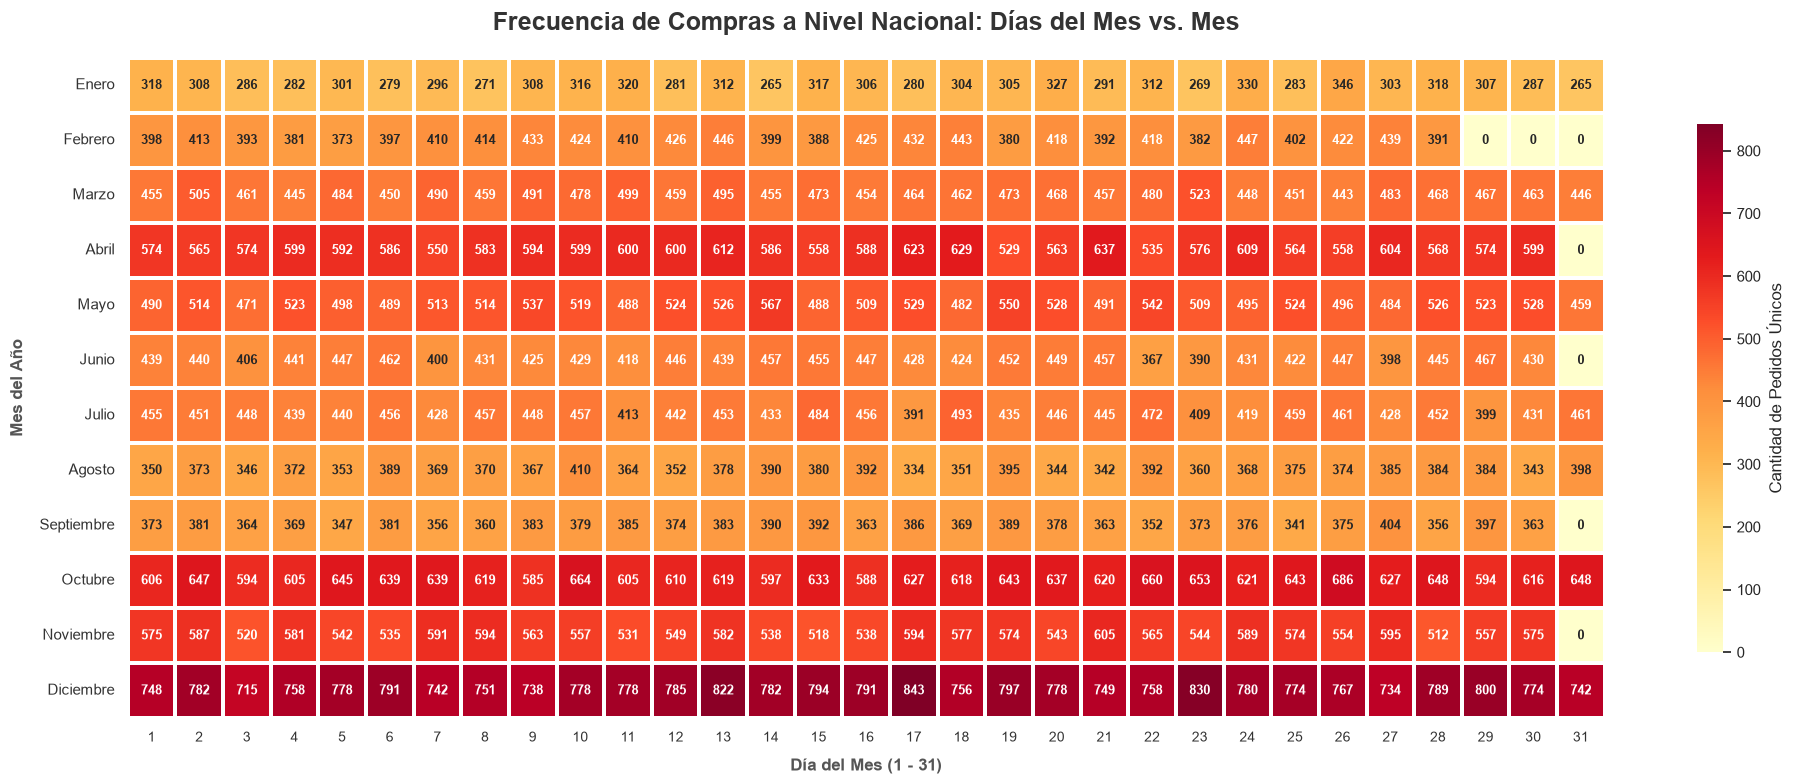

In [ ]:


#  Crear un diccionario 
meses_dict = dict(zip(range(1, 13), MESES_NOMBRES))


df['Mes_Nombre'] = df['Mes'].map(meses_dict)

# Ordenar las categorías para el gráfico usando directamente tu lista
df['Mes_Nombre'] = pd.Categorical(df['Mes_Nombre'], categories=MESES_NOMBRES, ordered=True)


heatmap_dias_mes = df.pivot_table(
    index="Mes_Nombre",     
    columns="Dia",          
    values="ID de Pedido", 
    aggfunc="nunique",      
    fill_value=0
)


fig, ax = plt.subplots(figsize=(20, 8), facecolor='#FFFFFF')

sns.heatmap(
    heatmap_dias_mes, 
    cmap="YlOrRd", 
    annot=True, 
    fmt="d",              
    linewidths=1.5,        
    linecolor='#FFFFFF',   
    cbar_kws={'label': 'Cantidad de Pedidos Únicos', 'shrink': 0.8},
    annot_kws={"size": 9, "weight": "bold"},
    ax=ax
)


ax.set_title('Frecuencia de Compras a Nivel Nacional: Días del Mes vs. Mes', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Día del Mes (1 - 31)', fontsize=12, fontweight='bold', labelpad=10, color='#555555')
ax.set_ylabel('Mes del Año', fontsize=12, fontweight='bold', labelpad=10, color='#555555')

ax.tick_params(axis='x', colors='#333333', labelsize=10)
ax.tick_params(axis='y', colors='#333333', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

¿Cómo varían lasventasa lo largo delosdiferentes díasdela semana

In [ ]:
# Extracción de fecha y hora
df['Mes'] = df['Fecha de Pedido'].dt.month
df['Dia'] = df['Fecha de Pedido'].dt.day
df['Hora'] = df['Fecha de Pedido'].dt.hour
df['Ciudad'] = df['Dirección de Envio'].apply(lambda x: str(x).split(',')[1].strip())
df['Venta'] = df['Cantidad Pedida'] * df['Precio Unitario']


df["dia_semana"] = df["Fecha de Pedido"].dt.day_name().map(dias_es)


orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
df["dia_semana"] = pd.Categorical(df["dia_semana"], categories=orden_dias, ordered=True)

heatmap_dias = df.pivot_table(
    index="dia_semana", 
    columns="Hora", 
    values="ID de Pedido", 
    aggfunc="nunique", 
    fill_value=0
)

# subplot
fig, ax = plt.subplots(figsize=(18, 7), facecolor='#FFFFFF')

sns.heatmap(
    heatmap_dias, 
    cmap="YlOrRd", 
    annot=True, 
    fmt="d",              
    linewidths=1.5,        
    linecolor='#FFFFFF',   
    cbar_kws={'label': 'Cantidad de Pedidos Únicos', 'shrink': 0.8},
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)


ax.set_title('Frecuencia de Compras: Días de la Semana vs. Hora del Día', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Hora del Día (0 - 23)', fontsize=12, fontweight='bold', labelpad=10, color='#555555')
ax.set_ylabel('Día de la Semana', fontsize=12, fontweight='bold', labelpad=10, color='#555555')


ax.tick_params(axis='x', colors='#333333', labelsize=11)
ax.tick_params(axis='y', colors='#333333', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

NameError: name 'dias_es' is not defined

Este: ?

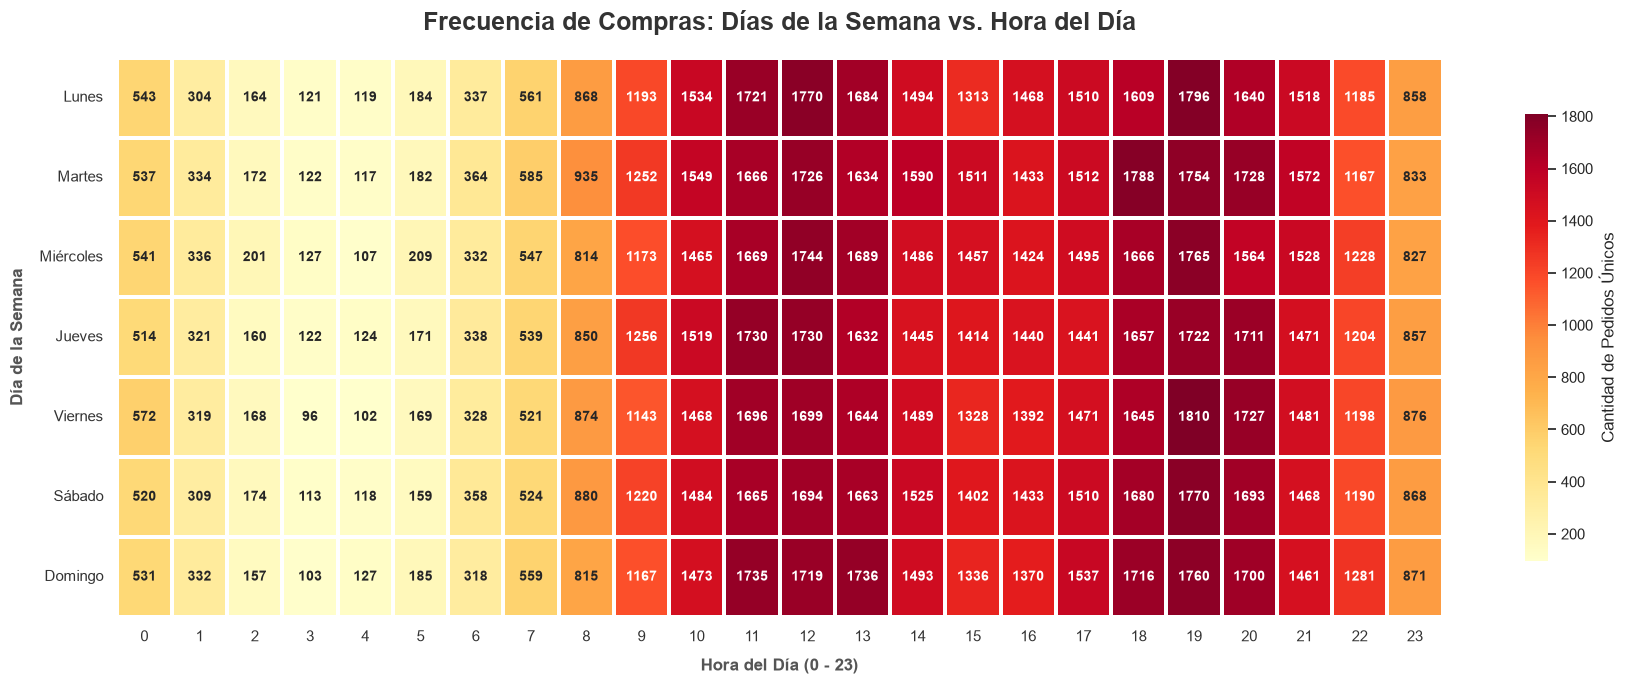

In [ ]:

orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

# 1. Agrupación y ordenamiento directo del resultado con reindex
heatmap_dias = (
    df.groupby(["dia_semana", "Hora"])["ID de Pedido"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(orden_dias)  # Ordena las filas del heatmap según tu lista sin tocar el df original
)

# 2. Creación del Gráfico
fig, ax = plt.subplots(figsize=(18, 7), facecolor='#FFFFFF')

sns.heatmap(
    heatmap_dias, 
    cmap="YlOrRd", 
    annot=True, 
    fmt="d",              
    linewidths=1.5,        
    linecolor='#FFFFFF',   
    cbar_kws={'label': 'Cantidad de Pedidos Únicos', 'shrink': 0.8},
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

# Estilizado
ax.set_title('Frecuencia de Compras: Días de la Semana vs. Hora del Día', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Hora del Día (0 - 23)', fontsize=12, fontweight='bold', labelpad=10, color='#555555')
ax.set_ylabel('Día de la Semana', fontsize=12, fontweight='bold', labelpad=10, color='#555555')

ax.tick_params(axis='x', colors='#333333', labelsize=11)
ax.tick_params(axis='y', colors='#333333', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

In [ ]:

orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

# 1. Transformación de datos: Creamos todas las columnas en un solo paso con .assign()
# Nota: Cambiamos el .apply() por .str.split() que es más rápido y nativo de Pandas.
df = df.assign(
    Mes=df['Fecha de Pedido'].dt.month,
    Dia=df['Fecha de Pedido'].dt.day,
    Hora=df['Fecha de Pedido'].dt.hour,
    Ciudad=df['Dirección de Envio'].str.split(',').str[1].str.strip(),
    Venta=df['Cantidad Pedida'] * df['Precio Unitario'],
    dia_semana=pd.Categorical(
        df['Fecha de Pedido'].dt.day_name().map(dias_es), 
        categories=orden_dias, 
        ordered=True
    )
)

# 2. Creación de los datos del Heatmap usando groupby + unstack
heatmap_dias = (
    df.groupby(["dia_semana", "Hora"], observed=False)["ID de Pedido"]
    .nunique()
    .unstack(fill_value=0)
)

# 3. Gráfico (Tu configuración de Seaborn/Matplotlib está perfecta)
fig, ax = plt.subplots(figsize=(18, 7), facecolor='#FFFFFF')

sns.heatmap(
    heatmap_dias, 
    cmap="YlOrRd", 
    annot=True, 
    fmt="d",              
    linewidths=1.5,        
    linecolor='#FFFFFF',   
    cbar_kws={'label': 'Cantidad de Pedidos Únicos', 'shrink': 0.8},
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

ax.set_title('Frecuencia de Compras: Días de la Semana vs. Hora del Día', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Hora del Día (0 - 23)', fontsize=12, fontweight='bold', labelpad=10, color='#555555')
ax.set_ylabel('Día de la Semana', fontsize=12, fontweight='bold', labelpad=10, color='#555555')

ax.tick_params(axis='x', colors='#333333', labelsize=11)
ax.tick_params(axis='y', colors='#333333', labelsize=11, rotation=0)

plt.tight_layout()
plt.show()

NameError: name 'dias_es' is not defined

## Para cada pedido con múltiples productos, generá todos los pares posibles de
productos comprados juntos, contabilizá cuántas veces aparece cada combinación
en todo el dataset y presentá los resultados en un heatmap.

C:\Users\Brenda\AppData\Local\Temp\ipykernel_18960\3577253534.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=frecuencias, y=combos, palette="Blues_r", edgecolor=".2")


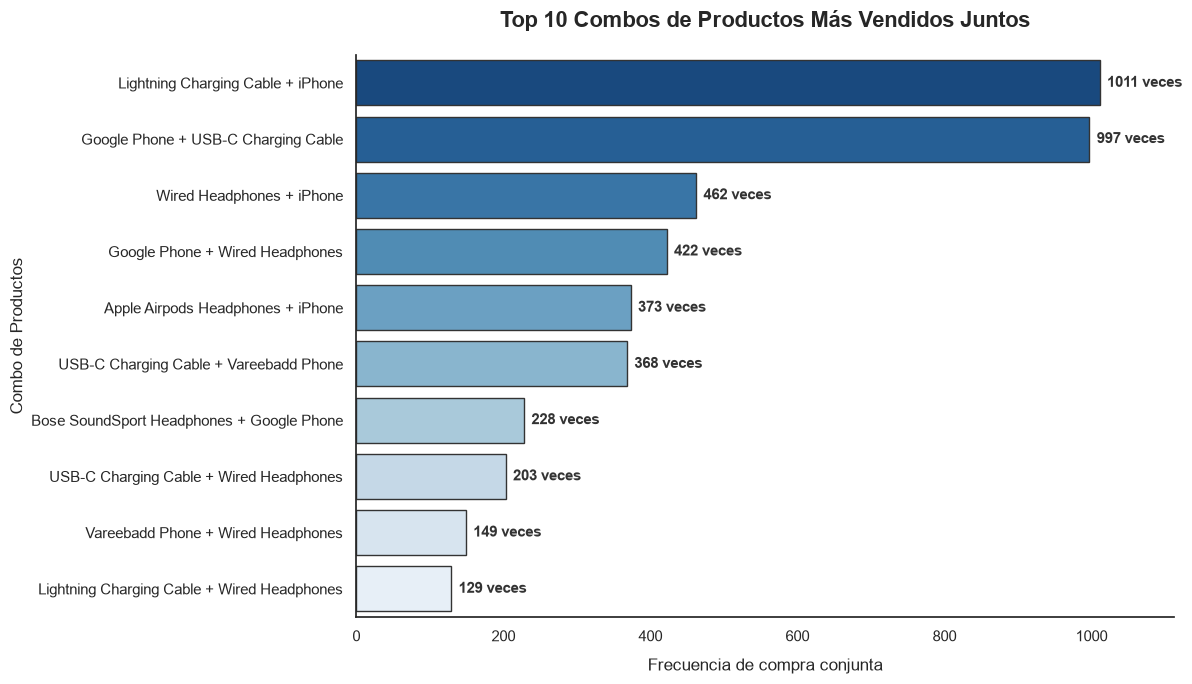

In [ ]:
# Filtramos pedidos múltiples y evitamos productos duplicados en el mismo pedido
df_multi = df[df['ID de Pedido'].duplicated(keep=False)]
pedidos_agrupados = df_multi.groupby('ID de Pedido')['Producto'].apply(lambda x: list(set(x)))

# Contamos las combinaciones de 2 productos
contador_pares = Counter()
for productos in pedidos_agrupados:
    productos_ordenados = sorted(productos)
    if len(productos_ordenados) >= 2:
        contador_pares.update(combinations(productos_ordenados, 2))

# Obtenemos específicamente los 10 combos más vendidos
top_10_combos = contador_pares.most_common(10)

# Preparamos listas separadas para el gráfico
combos = [" + ".join(par) for par, cantidad in top_10_combos]
frecuencias = [cantidad for par, cantidad in top_10_combos]


plt.figure(figsize=(12, 7))


ax = sns.barplot(x=frecuencias, y=combos, palette="Blues_r", edgecolor=".2")


for index, value in enumerate(frecuencias):
    ax.text(value + 10, index, f'{value} veces', color='#333333', va='center', fontweight='bold', fontsize=11)


plt.title("Top 10 Combos de Productos Más Vendidos Juntos", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Frecuencia de compra conjunta", fontsize=12, labelpad=10)
plt.ylabel("Combo de Productos", fontsize=12)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim(0, max(frecuencias) * 1.10) 

plt.tight_layout()
plt.show()

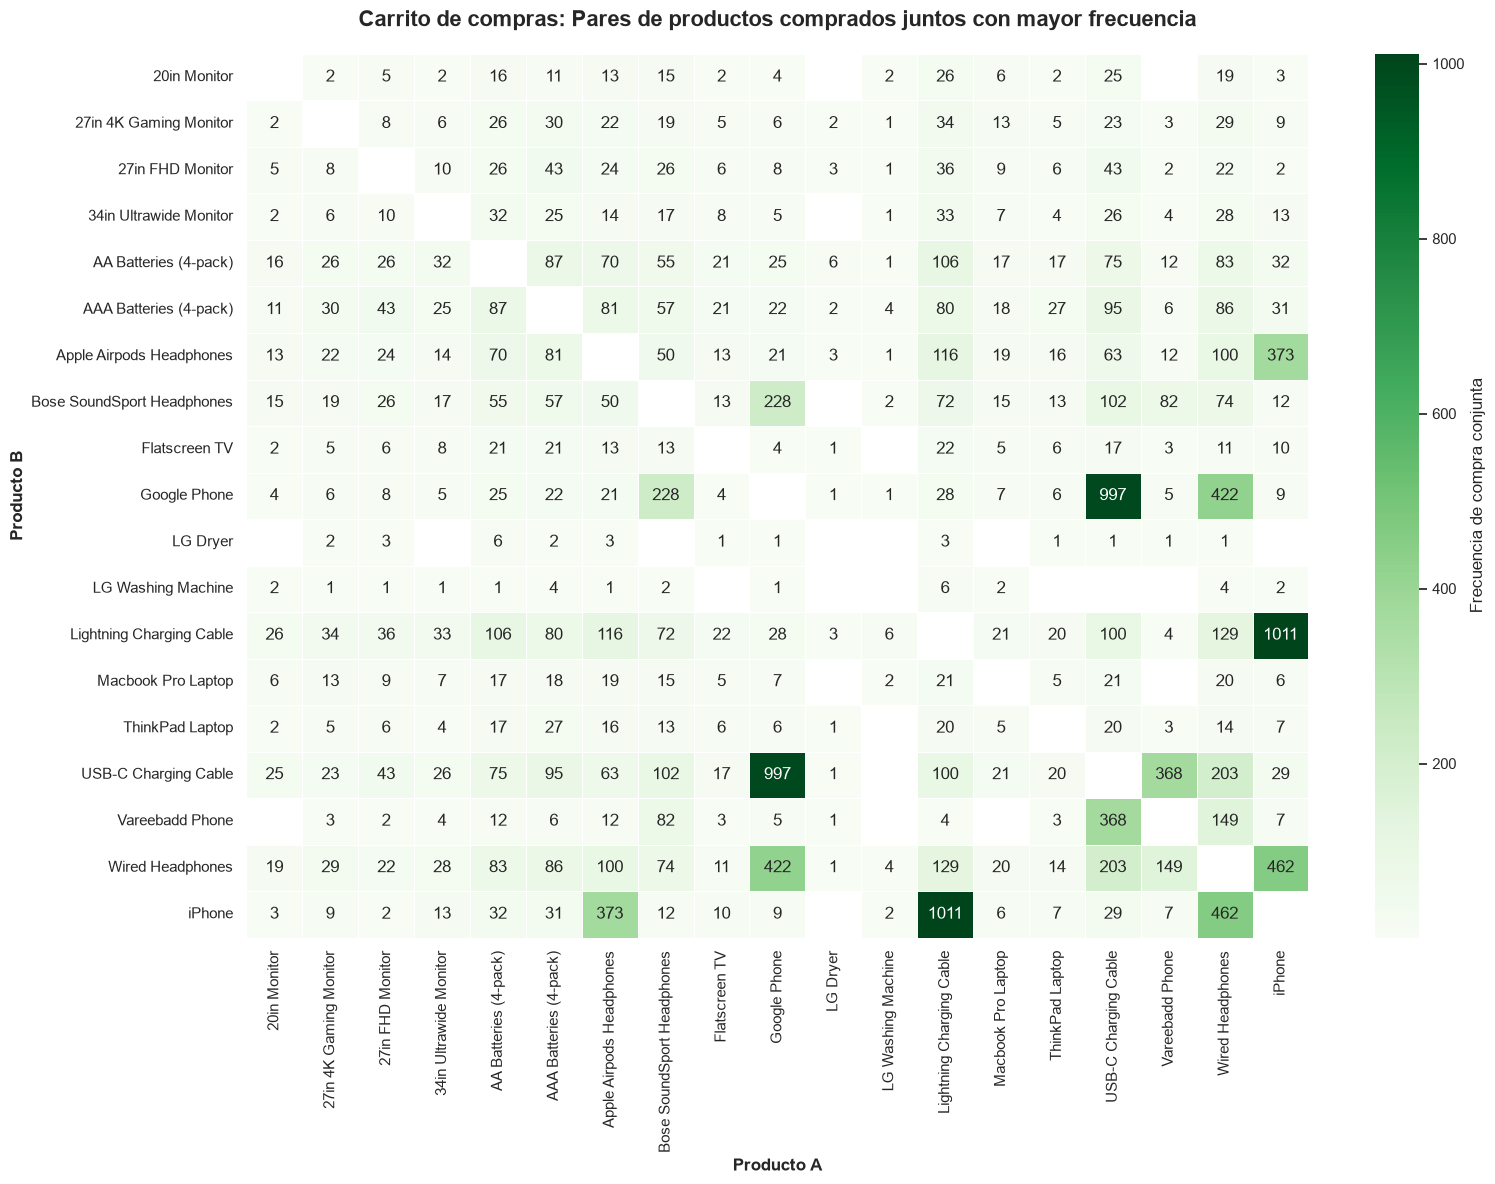

In [ ]:

# Filtramos solo los pedidos que tienen más de un producto
df_multi = df[df['ID de Pedido'].duplicated(keep=False)]

pedidos_agrupados = df_multi.groupby('ID de Pedido')['Producto'].apply(lambda x: list(set(x)))

# Generamos y contamos los pares posibles
contador_pares = Counter()

for productos in pedidos_agrupados:
    productos_ordenados = sorted(productos)
    
    if len(productos_ordenados) >= 2:
        contador_pares.update(combinations(productos_ordenados, 2))


registros = []
for (prod1, prod2), cantidad in contador_pares.items():
    registros.append({'Producto A': prod1, 'Producto B': prod2, 'Cantidad': cantidad})
      
    if prod1 != prod2:
        registros.append({'Producto A': prod2, 'Producto B': prod1, 'Cantidad': cantidad})


df_frecuencias = pd.DataFrame(registros)
matriz_pares = df_frecuencias.pivot_table(
    index='Producto A', 
    columns='Producto B', 
    values='Cantidad', 
    aggfunc='sum'
)


matriz_pares = matriz_pares.fillna(0).astype(int)

plt.figure(figsize=(16, 12))


mascara = matriz_pares == 0 

sns.heatmap(
    matriz_pares, 
    cmap="Greens",  
    # PuBu, Turbo       
    annot=True,         
    fmt="d",             
    linewidths=0.5, 
    mask=mascara,        
    cbar_kws={'label': 'Frecuencia de compra conjunta'}
)

plt.title("Carrito de compras: Pares de productos comprados juntos con mayor frecuencia", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Producto A", fontsize=12, fontweight='bold')
plt.ylabel("Producto B", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

hipotesis

In [ ]:
# Datos
ciudades = df_comparacion['Ciudad']
ventas = df_comparacion['Venta']
habitantes = df_comparacion['Habitantes']
ingreso_pc = df_comparacion['PerCapitaIncome_2023_USD']

x = np.arange(len(ciudades))
ancho = 0.35

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Eje izquierdo: Ventas (barras) ---
color_ventas = '#1f77b4'
barras_ventas = ax1.bar(
    x - ancho/2, ventas, ancho,
    label='Ventas Totales', color=color_ventas, zorder=3
)
ax1.set_ylabel('Ventas Totales ($)', color=color_ventas, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_ventas)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'${v/1e6:.1f}M'))

# --- Eje derecho: Habitantes (barras) e Ingreso per cápita (línea + puntos) ---
ax2 = ax1.twinx()

color_hab = "#f11b07"
barras_hab = ax2.bar(
    x + ancho/2, habitantes, ancho,
    label='Habitantes', color=color_hab, zorder=3, alpha=0.85
)
ax2.set_ylabel('Habitantes', color=color_hab, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_hab)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v/1e6:.1f}M'))

# --- Tercer eje (compartido): Ingreso per cápita como línea de puntos ---
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 70))  # Lo desplazamos hacia afuera
color_ing = '#2ca02c'
linea_ing, = ax3.plot(
    x, ingreso_pc,
    color=color_ing, marker='D', markersize=10,
    linestyle='-', linewidth=2, zorder=5,
    label='Ingreso per cápita 2023',
    markeredgecolor='black', markeredgewidth=1
)
ax3.set_ylabel('Ingreso per Cápita (USD)', color=color_ing, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_ing)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'${v/1e3:.0f}k'))
ax3.set_ylim(0, ingreso_pc.max() * 1.3)

# --- Eje X ---
ax1.set_xticks(x)
ax1.set_xticklabels(ciudades, rotation=45, ha='right', fontsize=11)
ax1.set_xlabel('Ciudad', fontsize=12, fontweight='bold')

# --- Título y leyenda ---
plt.title(
    'Perfil de Compradores por Ciudad:\nVentas, Población e Ingreso per Cápita',
    fontsize=15, fontweight='bold', pad=20
)

# Leyenda combinada de los tres ejes
lineas = [barras_ventas, barras_hab, linea_ing]
etiquetas = [l.get_label() for l in lineas]
# ver mejorar colores
ax1.legend(
    lineas, etiquetas,
    loc='upper right',
    fontsize=11,
    frameon=True,
    facecolor='white',
    edgecolor='gray',
    framealpha=1.0
)

ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

NameError: name 'df_comparacion' is not defined

In [80]:
# 1. Agrupamos las ventas totales por ciudad directamente desde el df principal
df_ventas = df.groupby('Ciudad', as_index=False)['Venta'].sum()

# 2. Si tus datos de habitantes e ingresos los tienes en un diccionario (como el que usaron en el lab):
datos_externos = {
    'Ciudad': ['Atlanta', 'Austin', 'Boston', 'Dallas', 'Los Angeles', 'New York City', 'Portland', 'San Francisco', 'Seattle'],
    'Habitantes': [530000, 1000000, 675000, 1300000, 3980000, 8260000, 652503, 827526, 781000],
    # Si tienes los ingresos per cápita en otra estructura, agrégalos aquí o únelos con un merge:
}
df_ciudades_info = pd.DataFrame(datos_externos)

# 3. Unimos las ventas con la info externa en un solo DataFrame de comparación limpio
df_comparacion = pd.merge(df_ventas, df_ciudades_info, on='Ciudad')

# (O si ya tienes un DataFrame externo con toda la info, simplemente haz:)
# df_comparacion['Venta'] = df.groupby('Ciudad')['Venta'].sum().values

In [81]:

# 1. Agrupación directa desde el DataFrame principal sin crear múltiples dataframes intermedios
df_comparacion = (
    df.groupby('Ciudad', as_index=False)
    .agg({
        'Venta': 'sum',
        'Habitantes': 'first',              # Asumiendo que esta columna ya existe en tu df
        'PerCapitaIncome_2023_USD': 'first' # Asumiendo que esta columna ya existe en tu df
    })
)

# 2. Extracción de las variables estrictamente necesarias para las coordenadas de Matplotlib
ciudades = df_comparacion['Ciudad']
ventas = df_comparacion['Venta']
habitantes = df_comparacion['Habitantes']
ingreso_pc = df_comparacion['PerCapitaIncome_2023_USD']

x = np.arange(len(ciudades))
ancho = 0.35

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Eje izquierdo: Ventas (barras) ---
color_ventas = '#1f77b4'
barras_ventas = ax1.bar(
    x - ancho/2, ventas, ancho,
    label='Ventas Totales', color=color_ventas, zorder=3
)
ax1.set_ylabel('Ventas Totales ($)', color=color_ventas, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_ventas)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'${v/1e6:.1f}M'))

# --- Eje derecho: Habitantes (barras) e Ingreso per cápita (línea + puntos) ---
ax2 = ax1.twinx()

color_hab = "#f11b07"
barras_hab = ax2.bar(
    x + ancho/2, habitantes, ancho,
    label='Habitantes', color=color_hab, zorder=3, alpha=0.85
)
ax2.set_ylabel('Habitantes', color=color_hab, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_hab)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v/1e6:.1f}M'))

# --- Tercer eje (compartido): Ingreso per cápita como línea de puntos ---
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 70))  # Lo desplazamos hacia afuera
color_ing = '#2ca02c'
linea_ing, = ax3.plot(
    x, ingreso_pc,
    color=color_ing, marker='D', markersize=10,
    linestyle='-', linewidth=2, zorder=5,
    label='Ingreso per cápita 2023',
    markeredgecolor='black', markeredgewidth=1
)
ax3.set_ylabel('Ingreso per Cápita (USD)', color=color_ing, fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_ing)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'${v/1e3:.0f}k'))
ax3.set_ylim(0, ingreso_pc.max() * 1.3)

# --- Eje X ---
ax1.set_xticks(x)
ax1.set_xticklabels(ciudades, rotation=45, ha='right', fontsize=11)
ax1.set_xlabel('Ciudad', fontsize=12, fontweight='bold')

# --- Título y leyenda ---
plt.title(
    'Perfil de Compradores por Ciudad:\nVentas, Población e Ingreso per Cápita',
    fontsize=15, fontweight='bold', pad=20
)

# Leyenda combinada de los tres ejes
lineas = [barras_ventas, barras_hab, linea_ing]
etiquetas = [l.get_label() for l in lineas]
ax1.legend(
    lineas, etiquetas,
    loc='upper right',
    fontsize=11,
    frameon=True,
    facecolor='white',
    edgecolor='gray',
    framealpha=1.0
)

ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

KeyError: "Label(s) ['Habitantes', 'PerCapitaIncome_2023_USD'] do not exist"

In [83]:
df.head(1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ID de Pedido        185950 non-null  int64         
 1   Producto            185950 non-null  string        
 2   Cantidad Pedida     185950 non-null  int64         
 3   Precio Unitario     185950 non-null  float64       
 4   Fecha de Pedido     185950 non-null  datetime64[us]
 5   Dirección de Envio  185950 non-null  string        
 6   Mes                 185950 non-null  int32         
 7   Dia                 185950 non-null  int32         
 8   dia_semana          185950 non-null  str           
 9   mes_nombre          185950 non-null  str           
 10  Hora                185950 non-null  int32         
 11  Ciudad              185950 non-null  str           
 12  Estado              185950 non-null  object        
 13  Venta               185950 non-null  flo

KeyError: 'Ventas_Millones_USD'

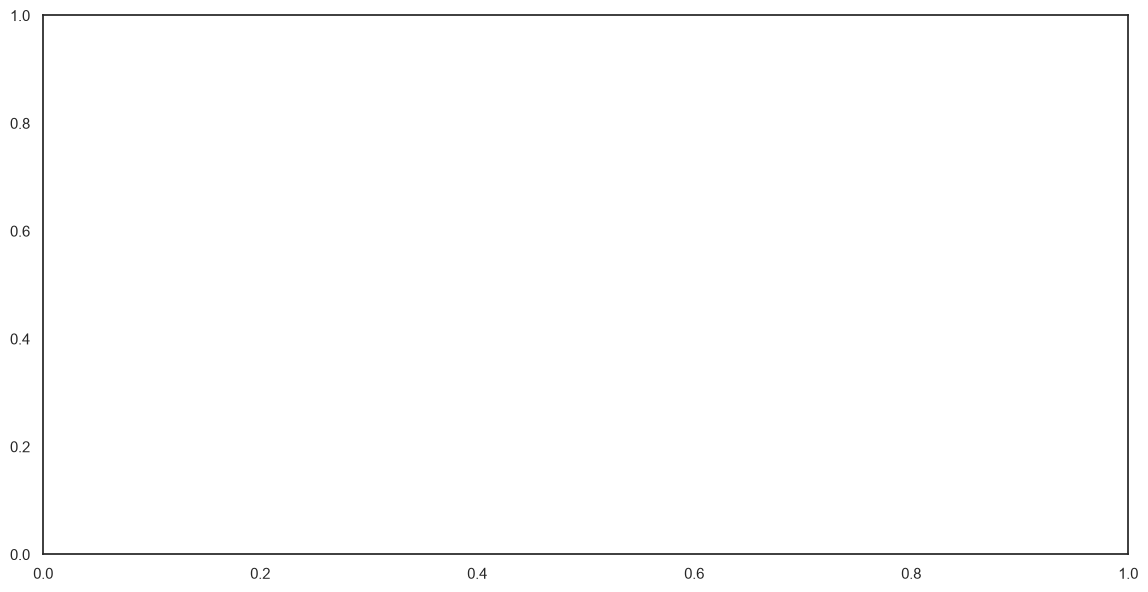

In [84]:

fig, ax1 = plt.subplots(figsize=(14, 7))

# Eje Y izquierdo: Ventas Totales en millones
color_barras = '#1f77b4'
bars = ax1.bar(df_comparacion['Ciudad'], df_comparacion['Ventas_Millones_USD'],
               color=color_barras, alpha=0.85, label='Ventas Totales (Millones USD)')
ax1.set_xlabel('Ciudad', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ventas Totales (Millones USD)', color=color_barras, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_barras)
ax1.set_xticklabels(df_comparacion['Ciudad'], rotation=45, ha='right', fontsize=11)

# Añadir etiquetas de valor encima de cada barra
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.2f}M',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1f77b4')

# Eje Y derecho: Ventas Per Cápita
ax2 = ax1.twinx()
color_linea = '#d62728'
line = ax2.plot(df_comparacion['Ciudad'], df_comparacion['Venta_PerCapita_USD'],
                color=color_linea, marker='o', linewidth=2.5, markersize=10,
                markerfacecolor='white', markeredgewidth=2, label='Venta Per Cápita (USD)')
ax2.set_ylabel('Venta Per Cápita (USD)', color=color_linea, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_linea)

# Añadir valores sobre los puntos de la línea
for i, valor in enumerate(df_comparacion['Venta_PerCapita_USD']):
    ax2.annotate(f'${valor:.2f}', (i, valor), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9, fontweight='bold', color=color_linea)

# Título y leyendas
plt.title('Comparación de Ventas Totales vs. Venta Per Cápita por Ciudad',
          fontsize=16, fontweight='bold', pad=20)

# Combinar leyendas de ambos ejes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=10, framealpha=0.95)

ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
plt.tight_layout()
plt.show()